In [ ]:
!pip install --upgrade scikit-learn xgboost pandas

## Introdução

Este projeto tem como objetivo realizar o processo de limpeza, tratamento, preparação de dados e análise exploratória (EDA), utilizando as bibliotecas de dados do Python (Pandas, Matplotlib, Seaborn e Numpy) visando a construção de modelos de Machine Learning capazes de gerar previsões e análises relevantes para o desenvolvimento do aplicativo do TCC.

### Contextualização e Cenário de Aplicação

O problema central que este projeto busca resolver é a dependência de métodos destrutivos para a avaliação da qualidade de mudas de arroz. Tradicionalmente, para verificar o impacto de microrganismos ou rizobactérias no desenvolvimento da planta através do Índice de Qualidade de Dickson (IQD), o engenheiro florestal ou agrônomo precisa sacrificar a muda, secá-la em estufa por dias e extrair os pesos secos da parte aérea e da raiz (PSA, PSR, PST).

Para otimizar esse processo, o aplicativo proposto atuará como uma ferramenta de **diagnóstico não-destrutivo em tempo real**. O cenário de uso consiste no profissional indo até o experimento em campo ou viveiro e, utilizando instrumentos simples como régua e paquímetro, aferir o Comprimento da Parte Aérea (PA_CM) e o Diâmetro do Coleto (mm) da planta **ainda viva e intacta no solo**. 

Ao inserir essas medidas biométricas no aplicativo, juntamente com os dados categóricos do experimento (Microrganismo inoculado, Cidade e tipo de Plantação), o sistema utilizará a inteligência artificial para processar o cruzamento dessas *features* e classificar imediatamente se o impacto no crescimento será "Padrão" ou "Alto". Essa abordagem economiza tempo de pesquisa, reduz custos laboratoriais e preserva o material biológico do experimento.

### Metodologia de Machine Learning

Inicialmente, será realizada a etapa de pré-processamento dos dados, envolvendo o tratamento de valores ausentes, remoção de inconsistências e a correta codificação das variáveis categóricas e numéricas para análise. 

Em seguida, serão treinados e avaliados três algoritmos distintos de aprendizado de máquina: 
* K-Nearest Neighbors (KNN)
* Random Forest
* XGBoost

O modelo XGBoost receberá atenção especial, sendo submetido a técnicas de ajuste de hiperparâmetros (*tuning*) para buscar a otimização máxima de seu desempenho no reconhecimento dos padrões não-destrutivos. Ao final do processo, os algoritmos serão rigorosamente comparados com base em suas métricas de validação, permitindo identificar o modelo mais robusto e com maior viabilidade técnica para ser integrado ao *backend* do aplicativo móvel preditivo.

In [1]:
# Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import scipy
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

In [2]:
# Carregando os dados
df = pd.read_excel('dados/biogrow_dados.xlsx')

In [3]:
df

,TRAT,Grupo,Cidade,Plantação,Repetição,PA_(CM),Diametro_do_coleto_(mm),PST_(mg),PSR_(mg),PSA_(mg),Comprimento_de_raiz_(CM),IQD
0,Testemunha,3,S/L,Cambará,1,37.50,1.24,39,14,25,7.00,0.563242
1,Testemunha,3,S/L,Cambará,2,26.00,1.10,39,14,25,7.50,0.622642
2,Testemunha,3,S/L,Cambará,3,31.00,1.12,39,14,25,5.00,0.584896
3,Testemunha,3,S/L,Cambará,4,29.50,1.43,39,14,25,9.00,0.654040
4,Testemunha,3,S/L,Cambará,5,35.00,1.98,39,14,25,10.00,0.688113
...,...,...,...,...,...,...,...,...,...,...,...,...
6035,ISO-266D,3,Don Eliseu,Sertaneja,36,39.95,1.12,42,11,31,8.66,0.540752
6036,ISO-266D,3,Don Eliseu,Sertaneja,37,39.95,1.35,42,11,31,8.66,0.586653
6037,ISO-266D,3,Don Eliseu,Sertaneja,38,39.95,1.23,42,11,31,8.66,0.563912
6038,ISO-266D,3,Don Eliseu,Sertaneja,39,39.95,1.90,42,11,31,8.66,0.666388


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TRAT                      6040 non-null   object 
 1   Grupo                     6040 non-null   int64  
 2   Cidade                    6040 non-null   object 
 3   Plantação                 6040 non-null   object 
 4   Repetição                 6040 non-null   int64  
 5   PA_(CM)                   6039 non-null   float64
 6   Diametro_do_coleto_(mm)   6040 non-null   float64
 7   PST_(mg)                  6040 non-null   int64  
 8   PSR_(mg)                  6040 non-null   int64  
 9   PSA_(mg)                  6040 non-null   int64  
 10  Comprimento_de_raiz_(CM)  6038 non-null   float64
 11  IQD                       6040 non-null   float64
dtypes: float64(4), int64(5), object(3)
memory usage: 566.4+ KB


## Limpeza de Dados

In [5]:
# Verificação de valores nulos
df.isnull().sum()

TRAT                        0
Grupo                       0
Cidade                      0
Plantação                   0
Repetição                   0
PA_(CM)                     1
Diametro_do_coleto_(mm)     0
PST_(mg)                    0
PSR_(mg)                    0
PSA_(mg)                    0
Comprimento_de_raiz_(CM)    2
IQD                         0
dtype: int64

In [ ]:
# Substituição de valores nulos pela mediana
df['PA_(CM)'] = df['PA_(CM)'].fillna(df['PA_(CM)'].median())
df['Comprimento_de_raiz_(CM)'] = df['Comprimento_de_raiz_(CM)'].fillna(df['Comprimento_de_raiz_(CM)'].median())

df.isnull().sum()

In [ ]:
# Verificando dados duplicados
df.duplicated().sum()

In [ ]:
df.columns

In [ ]:
# Removendo espaços de texto
df['TRAT'] = df['TRAT'].str.strip()
df['Cidade'] = df['Cidade'].str.strip()
df['Plantação'] = df['Plantação'].str.strip()

df.columns = df.columns.str.strip()

In [ ]:
# Verificando se há valores NaN
df.isna().sum()

## Tratamento de Outliers
### Sensibilidade do KNN aos Outliers

O algoritmo K-Nearest Neighbors (KNN) é altamente sensível à presença de outliers, pois seu funcionamento é baseado na distância entre os dados. Valores discrepantes podem alterar significativamente o cálculo das distâncias, fazendo com que determinadas amostras sejam classificadas incorretamente ou influenciem negativamente as previsões do modelo.

Por esse motivo, o tratamento de outliers é uma etapa importante no pré-processamento dos dados. A remoção ou adequação desses valores contribui para melhorar a qualidade das análises, reduzir ruídos no conjunto de dados e aumentar a precisão e confiabilidade do modelo de Machine Learning.

In [ ]:
# Seleciona as colunas numéricas
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Geração dos gráficos boxplot para identificar outliers
for i, coluna in enumerate(colunas_numericas, start=1):
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[coluna], color='skyblue')
    plt.title(f'Boxplot: {coluna}')

    # Salvando os gráficos
    plt.savefig(f'graficos/grafico_boxplot_{i}.png', bbox_inches='tight')
    
    plt.show()

### Análise dos gráficos Boxplot

Os gráficos não mostram outliers com valores discrepantes entre as colunas(Com excessão da coluna "PA_(CM)" que apresenta dois valores muito acima do normal). Logo, não será necessário remover todos os outliers, pois isso poderá comprometer a taxa de acerto do modelo KNN, que será o primeiro algoritmo usado para treinar o modelo.

In [6]:
df[df['PA_(CM)'] > 100]

,TRAT,Grupo,Cidade,Plantação,Repetição,PA_(CM),Diametro_do_coleto_(mm),PST_(mg),PSR_(mg),PSA_(mg),Comprimento_de_raiz_(CM),IQD
4545,ISO-171,5,Don Eliseu,Primavera,26,335.5,0.95,59,23,36,10.0,0.143149
5457,ISO-235,7,Paragominas,Primavera,18,444.0,2.54,64,24,40,17.5,0.268003


In [ ]:
df = df[df['PA_(CM)'] < 100]
df

In [ ]:
# Salvar dados limpos
df.to_excel('dados/biogrow_dados_limpos.xlsx', index=False)

## Análise Exploratória dos Dados (EDA)

In [ ]:
# Cálculo de estatísticas descritivas básicas
# Criação de tabela geral das estatísticas
tabela_stats = df.describe().T
tabela_stats

In [ ]:
# 4. Calcular Métricas Extras (Moda, Assimetria e Curtose)
# Valores Numéricos
numericos = df.select_dtypes(include=[np.number])

# Como pode haver mais de uma moda, pegamos a primeira (.iloc[0])
moda = numericos.mode().iloc[0]
assimetria = numericos.skew()
curtose = numericos.kurtosis()

# Adicionando as novas métricas na tabela principal
tabela_stats['Moda'] = moda
tabela_stats['Assimetria (Skewness)'] = assimetria
tabela_stats['Curtose (Kurtosis)'] = curtose

# Reorganizando as colunas
ordem = ['count', 'mean', 'Moda', '50%', 'std', 'min', 'max', 'Assimetria (Skewness)', 'Curtose (Kurtosis)']
tabela_final = tabela_stats[ordem]

# Renomeando as colunas
tabela_final = tabela_final.rename(columns={
    'count': 'Contagem', 
    'mean': 'Média', 
    '50%': 'Mediana', 
    'std': 'Desvio Padrão', 
    'min': 'Mínimo', 
    'max': 'Máximo'
})

# Salvando a tabela em planilha Excel
# tabela_final.to_excel('tabela_descritiva_tcc.xlsx')

display(tabela_final)

### 📊 O que são Assimetria (Skewness) e Curtose (Kurtosis)?

Na análise de dados, métricas básicas como média e desvio padrão não contam toda a história sobre o formato real da distribuição. Para o treinamento de modelos de *Machine Learning*, precisamos entender como esses dados estão espalhados, e é aí que entram a **Assimetria** e a **Curtose**.

#### 1. Assimetria (Skewness)
* **O que é:** Mede a falta de simetria dos dados em relação à média. Ela indica se a "massa" dos dados está acumulada mais para um lado ou para o outro.
* **Como interpretar:**
    * **Próximo a 0:** Distribuição perfeitamente simétrica (formato de sino da curva normal).
    * **Maior que 0 (Positiva):** A cauda direita é mais longa. Os dados se concentram em valores menores, mas existem alguns valores excepcionalmente altos puxando a média para cima.
    * **Menor que 0 (Negativa):** A cauda esquerda é mais longa. Os dados se concentram em valores maiores, com alguns valores excepcionalmente baixos.
* **Importância na Modelagem:** Muitos algoritmos tradicionais assumem que os dados são simétricos. Se a assimetria for muito severa, o modelo pode ficar enviesado, sendo necessário aplicar transformações (como logaritmo) para centralizar a distribuição.

#### 2. Curtose (Kurtosis)
* **O que é:** Mede o "peso" das caudas da distribuição. Em termos práticos, ela avalia a propensão da variável em gerar valores extremos (*outliers*), mesmo após a limpeza inicial.
* **Como interpretar (padrão da biblioteca Pandas):**
    * **Próximo a 0 (Mesocúrtica):** O peso das caudas é igual ao de uma distribuição normal.
    * **Maior que 0 (Leptocúrtica):** Caudas pesadas. Indica um pico mais agudo e uma probabilidade maior de encontrar dados extremos na base.
    * **Menor que 0 (Platicúrtica):** Caudas leves. A distribuição é mais achatada e os valores extremos são raros.
* **Importância na Modelagem:** Uma curtose alta é um alerta de que o seu modelo precisará lidar frequentemente com valores que fogem do padrão. Modelos baseados em árvores (como Random Forest e XGBoost) lidam muito bem com caudas pesadas, enquanto redes neurais ou regressões podem ter a performance prejudicada.

> **Em resumo:** A Assimetria mostra para *qual lado* os seus dados estão pendendo, enquanto a Curtose revela a *frequência de valores extremos* nas pontas da distribuição. Ambas guiam o engenheiro de dados nas decisões de transformação de variáveis e escolha do algoritmo.

## Análise Descritiva e Comportamento Distribucional das Variáveis

Após a etapa de pré-processamento e limpeza de dados (tratamento de valores nulos e remoção de *outliers* extremos), a base de dados consolidou-se em 6.038 observações. A análise estatística descritiva univariada revela importantes padrões de distribuição que fundamentarão as escolhas algorítmicas na fase de modelagem preditiva.

Abaixo, os principais achados divididos pelo comportamento métrico das variáveis agronômicas:

### 1. Variáveis com Distribuição Simétrica (Bem Comportadas)
Variáveis com assimetria (*Skewness*) próxima a zero indicam uma distribuição equilibrada em torno da média, assemelhando-se ao formato de sino de uma distribuição normal.

* **IQD (Índice de Qualidade de Dickson):** Demonstra alta simetria, com Média (0.643) praticamente idêntica à Mediana (0.646) e Assimetria muito baixa (-0.28). A Curtose de 0.84 indica uma leve concentração de dados ao redor da média, mas sem caudas problemáticas.
* **PA_(CM) (Parte Aérea):** Após o tratamento dos dados, a variável apresentou excelente simetria. A Média (36.35 cm) e a Mediana (36.00 cm) estão perfeitamente alinhadas, com uma Assimetria quase nula (-0.04). A variação natural vai de 3.4 cm a 66 cm.
* **Pesos Secos (PST e PSA):** O Peso Seco Total e o Peso Seco da Parte Aérea apresentam distribuições levemente achatadas (Curtose negativa, indicando platicurtose) e assimetria positiva suave (~0.4), o que significa uma levíssima inclinação para valores maiores, mas dentro de um padrão altamente aceitável para o treinamento de modelos.

### 2. Variáveis com Assimetria Positiva e Caudas Pesadas
Algumas métricas apresentaram um desvio em relação à normalidade teórica, com dados concentrados em valores menores e uma longa cauda estendendo-se para valores maiores.

* **Diâmetro do Coleto (mm):** É a variável com o comportamento mais atípico da base. Apresenta forte Assimetria positiva (2.29) e uma Curtose bastante elevada (12.38). Isso indica a presença de "caudas pesadas" – ou seja, embora a mediana seja 1.53 mm, existem medições válidas chegando até 5.63 mm. Na perspectiva da engenharia de software aplicada a dados, a preservação desses valores extremos é crucial, pois refletem fenômenos biológicos reais que o modelo precisa aprender. Algoritmos de aprendizado baseados em árvores de decisão, como o XGBoost, lidam nativamente bem com esse tipo de distribuição assimétrica e não exigem transformações (como logaritmo) nesta variável.
* **Comprimento de Raiz (CM) e PSR_(mg):** Ambas apresentam assimetria positiva moderada (~0.76 e ~0.83, respectivamente). No caso do comprimento da raiz, a média (11.8 cm) é tracionada para cima por valores máximos que chegam a 55.5 cm, distanciando-se da moda (6.0 cm). 

### 3. Considerações sobre a Variabilidade e Modelagem
A análise do Desvio Padrão em relação às médias indica que há variabilidade suficiente nos dados para que um modelo de *machine learning* consiga encontrar padrões discriminativos. O fato de a base de dados manter assimetrias naturais em variáveis como o Diâmetro reforça a escolha por modelos não-lineares, capazes de particionar o espaço de *features* sem a premissa estrita de normalidade multivariada.

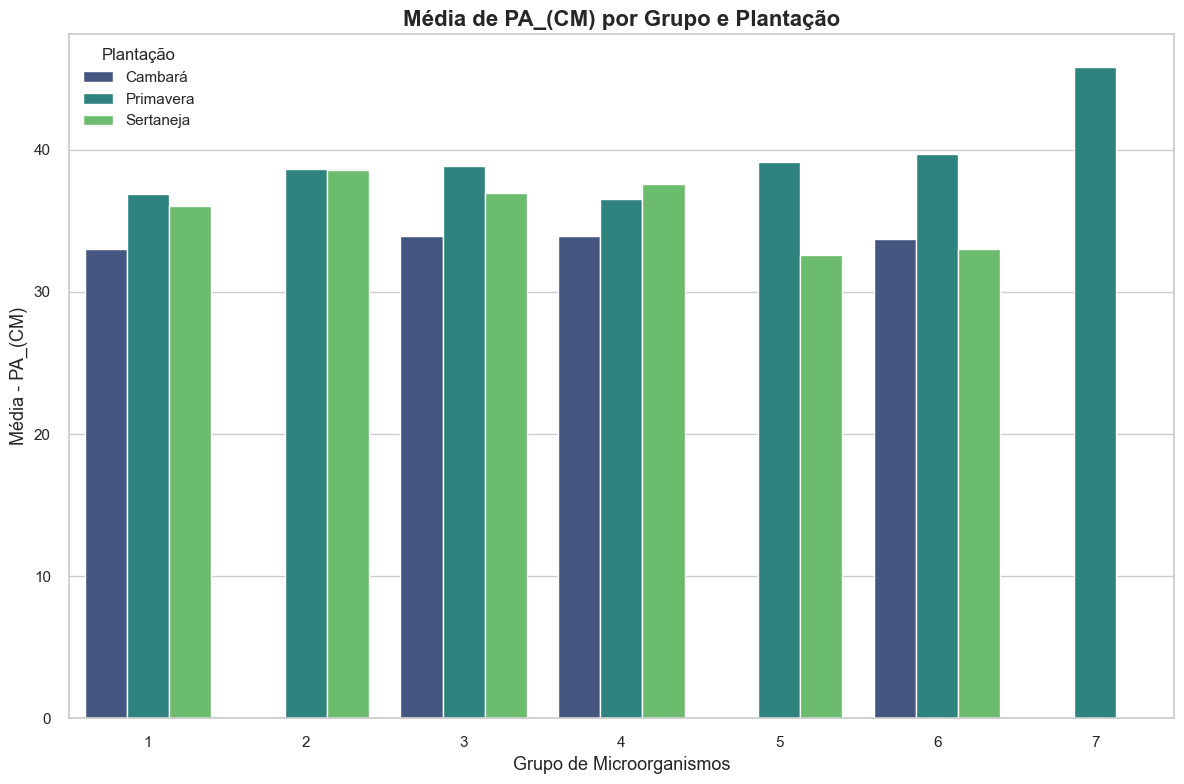

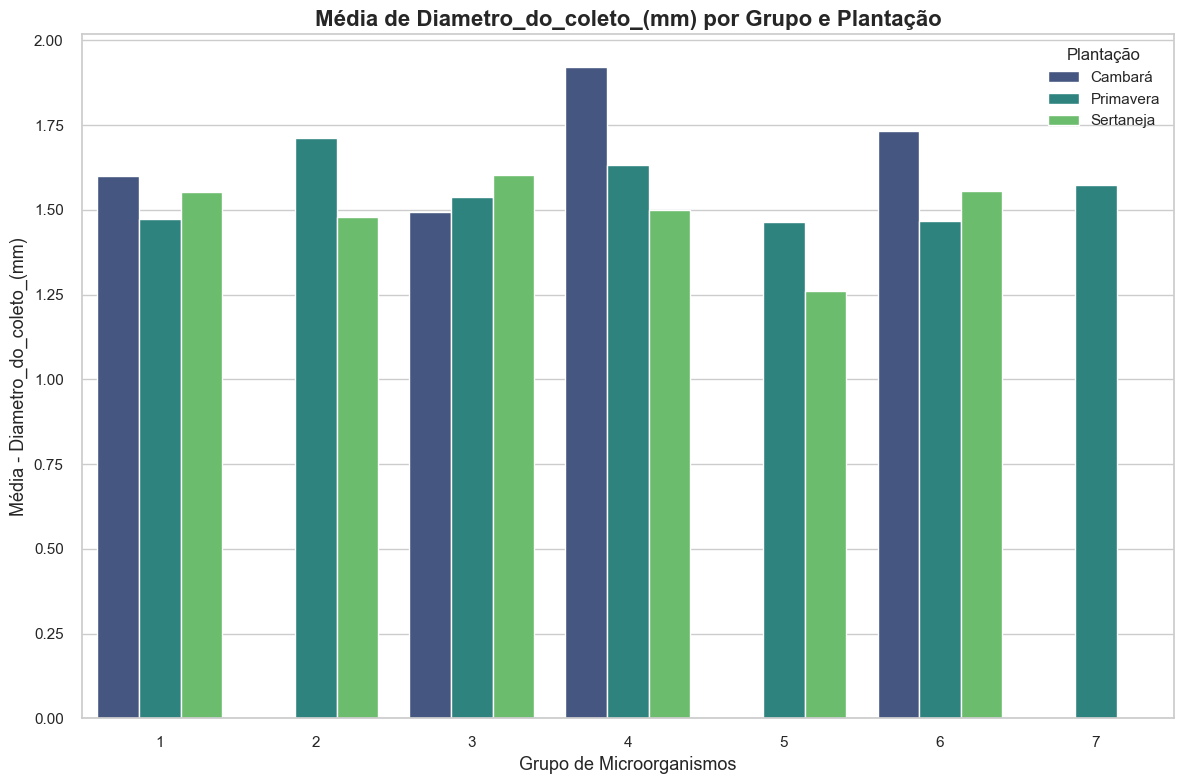

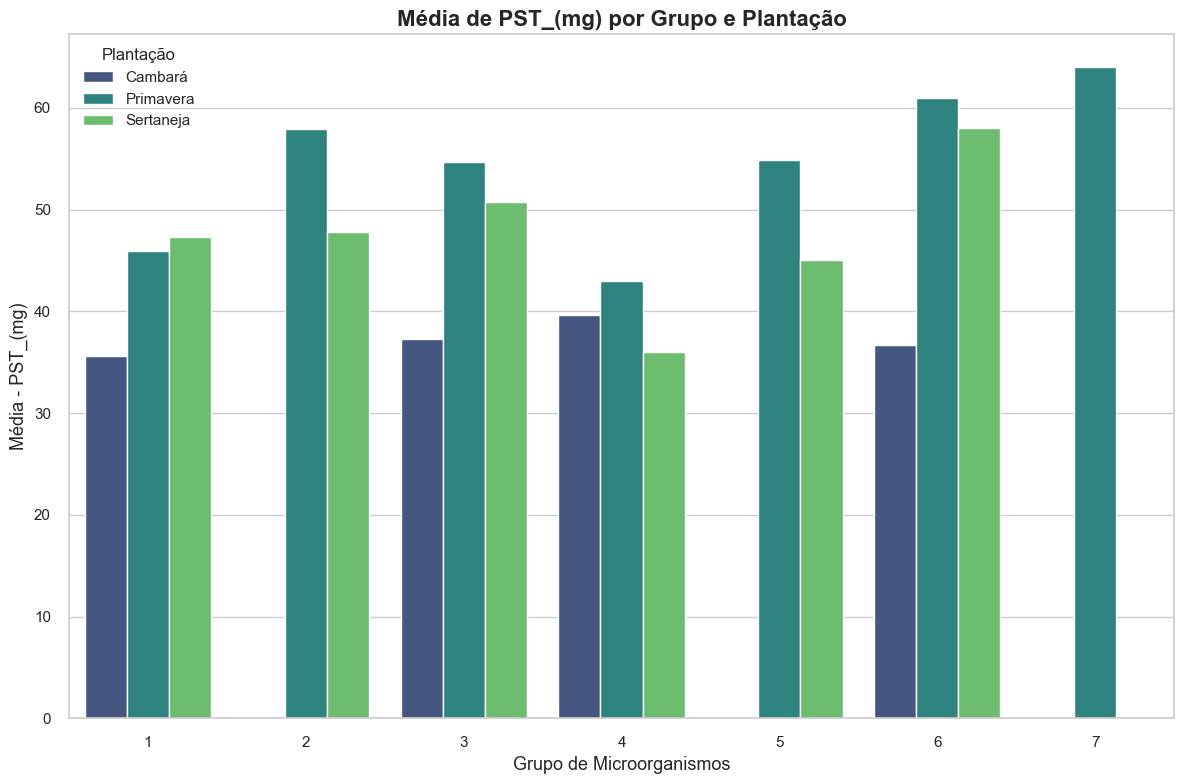

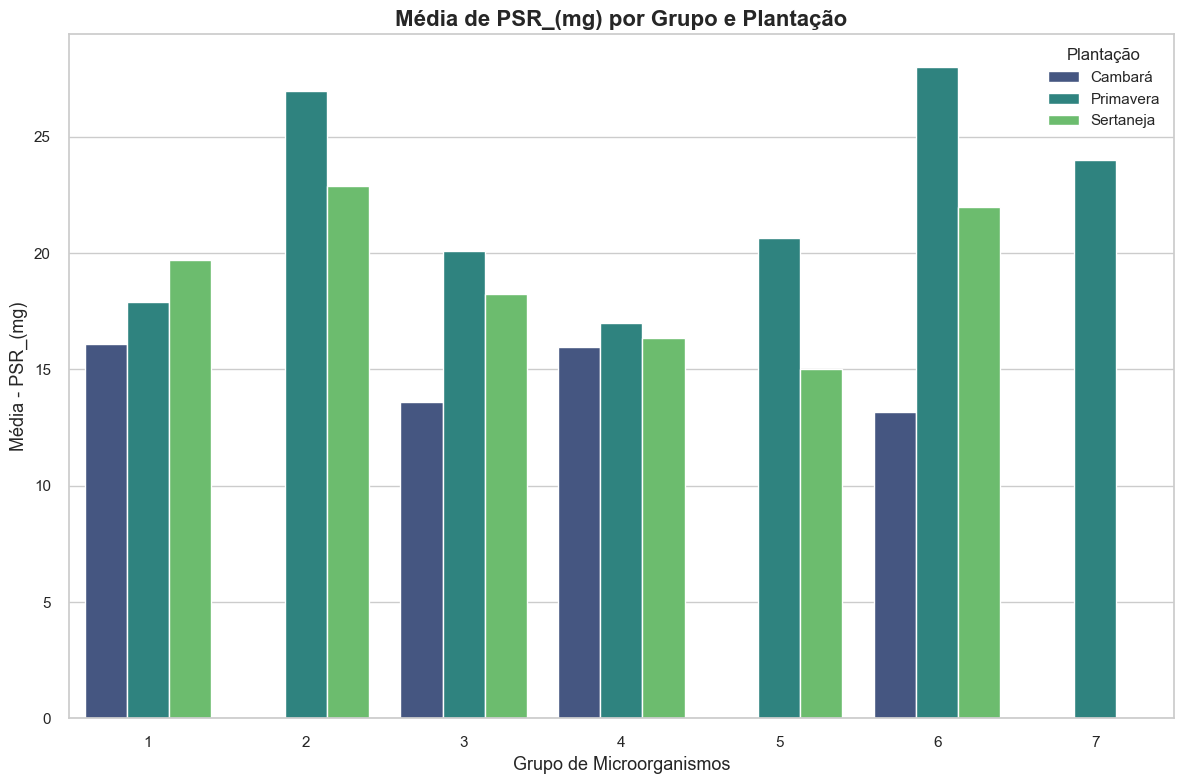

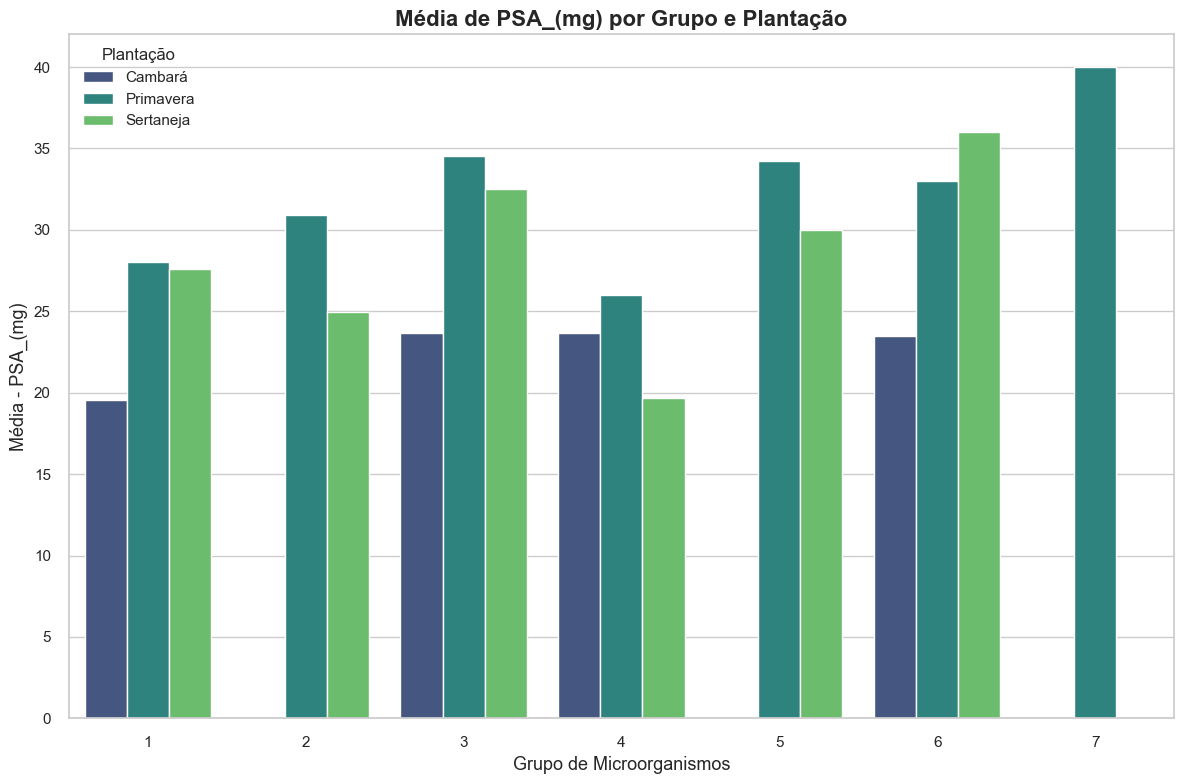

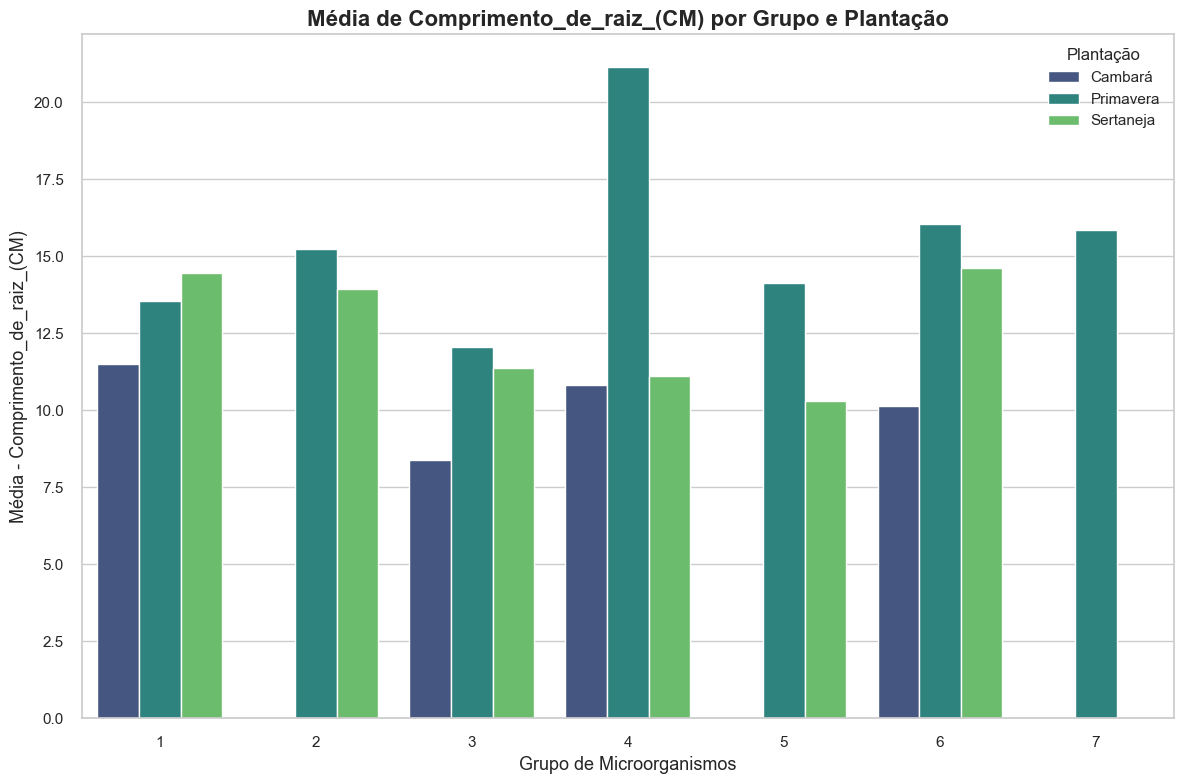

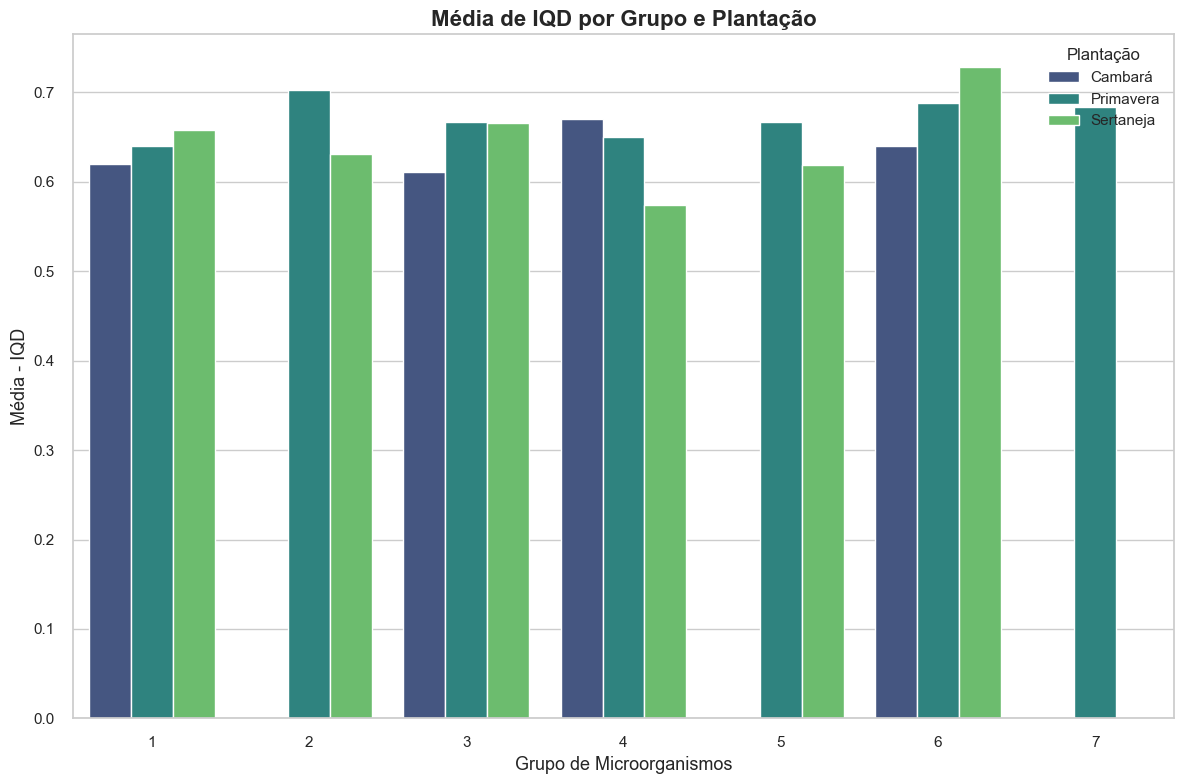

In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Filtro de segurança para o outlier extremo já discutido
if 'PA_(CM)' in df.columns:
    df = df[df['PA_(CM)'] < 400]

# Tratamento do Grupo para ordenação correta
df['Grupo'] = df['Grupo'].astype(str)
ordem_grupos = sorted(df['Grupo'].unique())

# Variáveis numéricas
variaveis_numericas = [
    'PA_(CM)', 'Diametro_do_coleto_(mm)', 'PST_(mg)',
    'PSR_(mg)', 'PSA_(mg)', 'Comprimento_de_raiz_(CM)', 'IQD'
]

sns.set_theme(style="whitegrid")

# Criar pasta para salvar os gráficos
os.makedirs('graficos_individuais', exist_ok=True)

for var in variaveis_numericas:

    # Cria uma nova figura para cada variável
    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=df,
        x='Grupo',
        y=var,
        hue='Plantação',
        palette='viridis',
        order=ordem_grupos,
        errorbar=None
    )

    plt.title(f'Média de {var} por Grupo e Plantação',
              fontsize=16,
              fontweight='bold')

    plt.xlabel('Grupo de Microorganismos', fontsize=13)
    plt.ylabel(f'Média - {var}', fontsize=13)

    plt.legend(title='Plantação', loc='best')

    plt.tight_layout()

    # Nome do arquivo sem caracteres problemáticos
    nome_arquivo = (
        var.replace('/', '_')
           .replace('(', '')
           .replace(')', '')
           .replace(' ', '_')
    )

    plt.savefig(
        f'graficos_individuais/{nome_arquivo}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close() 

## Análise Interpretativa: Desempenho Médio e Interação entre Grupos e Sistemas de Cultivo

A visualização por meio de barras agrupadas permitiu identificar padrões de crescimento e qualidade (IQD) que não seriam visíveis em uma análise univariada simples. Abaixo, destacam-se os principais *insights* extraídos do comportamento médio das variáveis:

### 1. Grupos de Elite e Potencial Preditivo
Ao observar métricas fundamentais como o **IQD (Índice de Qualidade de Dickson)** e a **PA (Parte Aérea)**, nota-se que os **Grupos 3, 5 e 6** apresentam consistentemente médias superiores aos demais. 
* O **Grupo 5**, em particular, destaca-se em quase todas as variáveis de biomassa (PST, PSR e PSA), sugerindo que este inóculo possui uma capacidade superior de promoção de crescimento, independentemente de fatores externos isolados.
* Para o modelo de *Machine Learning*, essa clara distinção entre grupos (barras com alturas bem diferentes) indica que a variável `Grupo` será uma das *features* com maior importância no particionamento das árvores de decisão.

### 2. Efeito do Sistema de Cultivo (Interação Grupo x Plantação)
O gráfico revela que o tipo de **Plantação** exerce um papel modulador no efeito dos microrganismos:
* Em variáveis como **Comprimento de Raiz** e **PST**, observa-se que alguns grupos respondem de forma distinta ao sistema de cultivo. Existem casos onde um sistema supera o outro significativamente dentro do mesmo grupo, enquanto em outros grupos o desempenho é estável.
* Essa "sensibilidade" ao sistema de cultivo é o que chamamos de efeito de interação. Se o modelo de predição fosse treinado apenas com o `Grupo`, ele perderia essa nuance. A inclusão da variável `Plantação` permitirá ao modelo capturar essas variações específicas de ambiente.

### 3. Estabilidade das Variáveis de Biomassa
As variáveis de massa (**PSA**, **PSR** e **PST**) seguem uma tendência de comportamento muito similar entre si em todos os grupos. Isso indica uma forte correlação positiva entre essas métricas. 
* Do ponto de vista de Engenharia de Software e Ciência de Dados, isso pode sugerir uma possível redundância de informações. Durante a modelagem, será importante verificar se todas essas massas são necessárias ou se uma delas (como a PST) já consegue representar o vigor da planta de forma satisfatória.

### 4. Conclusão da Análise de Médias
Os dados mostram que a inoculação não produz um efeito uniforme. O sucesso do crescimento vegetal é uma combinação específica entre a biologia do inóculo (`Grupo`) e a metodologia de cultivo (`Plantação`). 

Este painel de médias valida a premissa do TCC: existe uma lógica clara e padrões repetíveis nos dados, o que torna o conjunto de dados altamente apto para o treinamento de um modelo preditivo capaz de estimar a qualidade das mudas (IQD) e seu desenvolvimento físico com base nas condições iniciais de tratamento.

### Grupos 1 e 7
É possível observar que o Grupo 7 e o Grupo 1 (que costumam ser o controle ou grupos menos eficientes) aparecem com barras visivelmente menores em quase todos os gráficos. Essa diferença visual é a prova de que seu experimento funcionou e que os dados têm "sinal" suficiente para o algoritmo aprender a diferença entre uma planta bem tratada e uma planta com baixo desempenho.

In [ ]:
# Separar variáveis contínuas (excluindo variáveis de controle categóricas como Grupo e Repetição)
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
vars_continuas = [col for col in colunas_numericas if col not in ['Grupo', 'Repetição']]

# Criação do gráfico de matriz de correlação
# Correlação de Spearman
corr_matrix = df[vars_continuas].corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True,        
            cmap='coolwarm',     
            fmt=".2f",           
            linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Matriz de Correlação (Spearman)', fontsize=14)

plt.tight_layout()

plt.savefig('graficos/matriz_correlação.png', dpi = 300, bbox_inches = "tight")

plt.show()

## Teste de Normalidade dos Dados

In [8]:
import pandas as pd
from scipy.stats import shapiro
from IPython.display import display

# Variáveis numéricas
variaveis = [
    'PA_(CM)', 'Diametro_do_coleto_(mm)', 'PST_(mg)', 
    'PSR_(mg)', 'PSA_(mg)', 'Comprimento_de_raiz_(CM)', 'IQD'
]

# Lista para guardar os resultados
resultados = []

# O Teste de Normalidade Shapiro-Wilk em cada Grupo
for col in variaveis:
    for grupo in sorted(df['Grupo'].unique()):
        
        dados = df[df['Grupo'] == grupo][col].dropna()
        
        # O teste de Shapiro exige pelo menos 3 amostras para rodar
        if len(dados) >= 3: 
            stat, p_valor = shapiro(dados)
            
            # Se p-valor > 0.05 significa que a distribuição É Normal
            normal = "Sim" if p_valor > 0.05 else "Não"
            
            # Formatação de texto
            p_valor_fmt = f"{p_valor:.4e}" if p_valor < 0.0001 else f"{p_valor:.4f}"
            
            # Adiciona o resultado na lista
            resultados.append({
                'Variável': col,
                'Grupo': grupo,
                'Estatística W': round(stat, 4),
                'p-valor': p_valor_fmt,
                'Normal? (p > 0.05)': normal
            })

# Transforma os resultados num DataFrame
df_shapiro = pd.DataFrame(resultados)

# Salvando a tabela em formato Excel (.xlsx)
df_shapiro.to_excel('resultado_teste_normalidade.xlsx', index=False)

display(df_shapiro)

# Contagem de quantos testes deram "Normal" e "Não Normal"
print(df_shapiro['Normal? (p > 0.05)'].value_counts())

C:\Users\joaop\AppData\Roaming\Python\Python38\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


,Variável,Grupo,Estatística W,p-valor,Normal? (p > 0.05)
0,PA_(CM),1,0.9929,1.5399e-05,Não
1,PA_(CM),2,0.9894,2.0677e-07,Não
2,PA_(CM),3,0.9932,2.4312e-10,Não
3,PA_(CM),4,0.9814,0.0004,Não
4,PA_(CM),5,0.9300,1.0357e-05,Não
5,PA_(CM),6,0.9800,0.0002,Não
6,PA_(CM),7,0.9418,0.0437,Não
7,Diametro_do_coleto_(mm),1,0.8539,6.2434e-32,Não
8,Diametro_do_coleto_(mm),2,0.8440,2.7894e-32,Não
9,Diametro_do_coleto_(mm),3,0.8672,3.6434e-44,Não


Normal? (p > 0.05)
Não    45
Sim     4
Name: count, dtype: int64


## Teste de Normalidade de Shapiro-Wilk e Implicações Algorítmicas

Para comprovar com rigor estatístico o comportamento empírico observado na etapa visual, os dados foram submetidos ao teste de normalidade de **Shapiro-Wilk** ($p-valor < 0.05$). Visando preservar a integridade biológica, o teste foi aplicado de forma estratificada por `Grupo` de tratamento.

**Justificativa Metodológica do Teste:** A escolha específica do algoritmo de Shapiro-Wilk fundamenta-se em seu elevado poder estatístico (*statistical power*). Na literatura de ciência de dados e estatística aplicada, ele é amplamente reconhecido como o método mais sensível e rigoroso para detectar desvios em relação à distribuição normal teórica em variáveis contínuas, superando testes alternativos como o Kolmogorov-Smirnov. Sua aplicação direta nas subamostras (grupos) garante a máxima confiabilidade na validação da distribuição empírica.

**Resultados do Teste:**
A análise estatística rejeitou a hipótese nula ($H_0$) na esmagadora maioria dos cruzamentos (45 resultados não-normais contra apenas 4 normais). Isso confirma matematicamente que as medições agronômicas (Massa, Diâmetro, Altura e IQD) não seguem uma distribuição Gaussiana teórica perfeita. 

Em contextos biológicos e agronômicos de larga amostragem, esse resultado é esperado devido à sensibilidade do teste de Shapiro-Wilk a pequenos desvios da normalidade e à variabilidade inerente aos organismos vivos (presença de caudas pesadas naturais).

**Impacto na Arquitetura de Machine Learning:**
Do ponto de vista de Engenharia de Software, este laudo estatístico definitivo exclui o uso ideal de modelos paramétricos tradicionais (como regressão linear clássica ou *Naive Bayes Gaussiano*), que exigem premissas estritas de normalidade para não gerarem viés matemático. 

A não-normalidade provada fortalece e justifica cientificamente a escolha por **algoritmos não-paramétricos**, especialmente métodos de *Ensemble* baseados em árvores (como **Random Forest** ou **XGBoost**), que particionam os dados de forma não-linear, sem exigir qualquer pressuposto sobre o formato da distribuição das *features*.

In [ ]:
# Gráfico de Avaliação Visual de Normalidade 1: Histograma KDE
sns.set_theme(style="whitegrid")

# Colunas para plotagem
cols_to_plot = [
    'PA_(CM)', 'Diametro_do_coleto_(mm)', 'PST_(mg)', 
    'PSR_(mg)', 'PSA_(mg)', 'Comprimento_de_raiz_(CM)', 'IQD'
]

# Criação de Gráficos de Histogramas Com Curva De Densidade (KDE)
# Cria uma grade de gráficos (3 linhas por 3 colunas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

# Esconde os "quadrados" vazios que sobrarem na grade 3x3
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig('graficos/histograma_KDE.png', dpi = 300, bbox_inches = "tight")

plt.show()

## Interpretação Visual da Distribuição das Variáveis (Histogramas e KDE)

A avaliação visual por meio de histogramas combinados com a curva de Estimativa de Densidade de Kernel (KDE - *Kernel Density Estimation*) é uma etapa fundamental da Análise Exploratória de Dados. Ela permite identificar o formato da distribuição empírica das variáveis contínuas antes da aplicação de testes estatísticos formais de normalidade. 

A partir do painel de distribuições gerado, os dados podem ser classificados em três comportamentos principais:

### 1. Simetria e Aderência à Normalidade
* **IQD:** Apresenta o comportamento mais simétrico da base de dados, formando uma curva em sino quase perfeita. Isso indica que a maioria das amostras se concentra ao redor da média, com dispersão equilibrada para ambos os lados.
* **PA_(CM):** Também exibe uma distribuição centralizada e simétrica, corroborando com os indicadores matemáticos de assimetria próximos a zero estabelecidos na etapa de estatística descritiva.

### 2. Assimetria Positiva Forte (Caudas Longas à Direita)
* **Diametro_do_coleto_(mm) e Comprimento_de_raiz_(CM):** Ambas as variáveis exibem uma densidade concentrada à esquerda (valores menores) e uma longa cauda que se estende para a direita. Este comportamento visualiza a existência de *outliers* naturais e de assimetria positiva (*positive skew*). Biologicamente, indica que a maioria das plantas possui diâmetro e raízes em um espectro menor, mas algumas poucas amostras atingem tamanhos excepcionalmente maiores.

### 3. Assimetria Leve e Moderada
* **Pesos de Biomassa (PST_(mg), PSR_(mg) e PSA_(mg)):** As variáveis relacionadas ao peso seco da planta mostram um comportamento intermediário. Embora haja um leve alongamento da curva para o lado direito (valores mais altos), o desvio em relação ao formato de sino é suave se comparado ao diâmetro do coleto.

### Implicações para a Modelagem (Machine Learning)
A visualização confirma que o conjunto de dados é heterogêneo quanto à sua distribuição teórica. A presença de forte assimetria em características vitais (como o Diâmetro) alerta que algoritmos lineares clássicos poderiam apresentar viés (*bias*) ao tentar traçar fronteiras de decisão. 

Consequentemente, do ponto de vista de arquitetura de software para os modelos preditivos, este comportamento empírico justifica e favorece a escolha de modelos não-paramétricos baseados em árvores (como *Random Forest* ou *XGBoost*), que são inerentemente robustos contra distribuições assimétricas e variações de escala, dispensando a necessidade de transformações matemáticas (como *log* ou *Box-Cox*) sobre as *features* originais.

In [ ]:
# Gráfico de Avaliação Visual de Normalidade 2: Q-Q PLOTS
fig2, axes2 = plt.subplots(3, 3, figsize=(15, 12))
axes2 = axes2.flatten()

for i, col in enumerate(cols_to_plot):
    # stats.probplot compara os dados com uma distribuição normal teórica
    stats.probplot(df[col].dropna(), dist="norm", plot=axes2[i])
    axes2[i].set_title(f'Q-Q Plot: {col}', fontsize=12, fontweight='bold')
    axes2[i].set_xlabel('Quantis Teóricos (Normal)')
    axes2[i].set_ylabel('Valores Reais da Amostra')
    
    # Ajustes de cores
    axes2[i].get_lines()[0].set_markerfacecolor('steelblue')
    axes2[i].get_lines()[0].set_markersize(3)
    axes2[i].get_lines()[1].set_color('red')
    axes2[i].get_lines()[1].set_linewidth(2)

for j in range(len(cols_to_plot), len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()

plt.savefig('graficos/graficos_QQ.png', dpi = 300, bbox_inches = "tight")

plt.show()

### 📈 Entendendo os Gráficos Q-Q (Quantil-Quantil)

**Como funciona:**
O Q-Q Plot é uma ferramenta visual para validar a normalidade dos dados, comparando a nossa base real com uma distribuição teórica perfeita. 
* **Linha Vermelha:** Representa o "cenário ideal" de uma distribuição perfeitamente normal e simétrica.
* **Pontos Azuis:** Representam os decis dos seus dados reais.
* **Interpretação:** Se os dados forem normais, os pontos azuis ficarão perfeitamente alinhados sobre a linha vermelha. Desvios nas pontas (formando curvas ou "S") indicam assimetria e caudas pesadas.

**O que estamos vendo nestes gráficos:**
* **Aderência à Normalidade (IQD e PA):** Os pontos azuis acompanham a linha vermelha de forma muito consistente na maior parte do trajeto, confirmando que são as variáveis com comportamento mais simétrico da base.
* **Forte Assimetria (Diâmetro e Comprimento de Raiz):** No canto superior direito, os pontos "decolam" e se distanciam abruptamente da linha vermelha. Isso evidencia graficamente a presença de caudas longas à direita (assimetria positiva forte), o que significa que há medições biologicamente extremas puxando a distribuição.
* **Comportamento Intermediário (Pesos - PST, PSR, PSA):** Apresentam bom alinhamento no centro da curva, mas sofrem leves descolamentos na extremidade superior, indicando uma assimetria apenas moderada.

## Teste de Hipótese

In [ ]:
variavel_grupo = 'TRAT'
variaveis_analise = ['PA_(CM)', 'Diametro_do_coleto_(mm)', 'PST_(mg)', 'PSR_(mg)', 'PSA_(mg)', 'Comprimento_de_raiz_(CM)', 'IQD']
alfa = 0.05 

print("Iniciando análises... Aguarde, o resultado será salvo em Excel.")

# Criar um escritor de Excel para salvar os resultados em abas
with pd.ExcelWriter('Resultados_Estatisticos_Biogrow.xlsx') as writer:
    
    # Criar uma lista para um resumo geral
    resumo_anova = []

    for variavel in variaveis_analise:
        # Remover nulos para a variável atual
        df_limpo = df[[variavel_grupo, variavel]].dropna()
        
        grupos = df_limpo[variavel_grupo].unique()
        dados_por_grupo = [df_limpo[df_limpo[variavel_grupo] == grupo][variavel] for grupo in grupos]
        
        # ANOVA
        estatistica_f, valor_p = stats.f_oneway(*dados_por_grupo)
        houve_diferenca = "Sim" if valor_p < alfa else "Não"
        
        resumo_anova.append({
            'Variável': variavel, 
            'P-Value (ANOVA)': valor_p, 
            'Diferença Significativa?': houve_diferenca
        })
        
        # Se houve diferença, roda o Tukey e salva na aba do Excel
        if valor_p < alfa:
            tukey = pairwise_tukeyhsd(endog=df_limpo[variavel], groups=df_limpo[variavel_grupo], alpha=alfa)
            
            # Converter resultado do Tukey para DataFrame
            tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
            tukey_significativo = tukey_df[tukey_df['reject'] == True].sort_values(by='meandiff', ascending=False)
            
            # Salvar no Excel (Nome da aba será o nome da variável, limitado a 30 caracteres)
            nome_aba = variavel[:30].replace('/', '_') 
            tukey_significativo.to_excel(writer, sheet_name=nome_aba, index=False)

    # Salvar o resumo geral da ANOVA na primeira aba
    pd.DataFrame(resumo_anova).to_excel(writer, sheet_name='Resumo_ANOVA', index=False)

print("Análise concluída com sucesso!")
print("Abra o arquivo 'Resultados_Estatisticos_Biogrow.xlsx' na sua pasta para ver os resultados limpos.")

### Análise Estatística do Crescimento Vegetal

Para validar o impacto da inoculação de diferentes rizobactérias e fungos no desenvolvimento de plantas de arroz, adotamos uma abordagem estatística baseada em dois passos: a Análise de Variância (ANOVA) seguida pelo Teste de Comparações Múltiplas de Tukey.

#### 1. Justificativa das Escolhas Estatísticas

* **Por que a ANOVA (One-way ANOVA)?**
    O objetivo central do estudo é comparar as médias de diversas variáveis contínuas (como Peso Seco, Diâmetro do Coleto, etc.) através de **múltiplos grupos independentes** (os diferentes tratamentos + a testemunha). Se tentássemos usar vários "Testes T" para comparar as bactérias duas a duas, a chance de cometermos um Erro do Tipo I (apontar um falso positivo) aumentaria drasticamente a cada nova comparação. A ANOVA resolve esse problema analisando a variância global do experimento de uma só vez para nos dizer se existe alguma diferença real entre os tratamentos.

* **Por que o Teste de Tukey (Post-Hoc)?**
    A ANOVA possui uma limitação: ela nos dá uma resposta "geral". Se ela aponta que há diferença, ela não nos diz *qual* bactéria foi melhor ou pior, apenas afirma que pelo menos uma é diferente das demais. Para descobrir exatamente onde estão essas diferenças, precisamos de um teste *Post-Hoc* (pós-teste). O **Teste de Tukey (HSD)** foi escolhido por ser um dos métodos mais robustos e seguros para realizar todas as comparações possíveis em pares (Ex: Cepa A vs Testemunha; Cepa A vs Cepa B), controlando a taxa de erro e garantindo a confiabilidade dos achados.

---

#### 2. Interpretação dos Resultados

**A. Resultado da Análise Global (ANOVA)**
* **Constatação:** Para **todas** as variáveis fisiológicas analisadas (PA, Diâmetro do Coleto, PST, PSR, PSA, Comprimento de Raiz e IQD), o **Valor-p (p-value) foi igual a 0.0**.
* **Conclusão:** Como o valor-p obtido é estritamente inferior ao nível de significância adotado de 5% (alfa = 0,05), nós **rejeitamos a Hipótese Nula (H0)**. Isso comprova estatisticamente que o tipo de tratamento aplicado afeta o desenvolvimento da planta. Em outras palavras, as diferenças de crescimento observadas não ocorreram ao acaso; a inoculação teve um impacto significativo nas plantas de arroz.

**B. Resultado das Comparações Múltiplas (Teste de Tukey)**
* **Constatação:** As planilhas geradas detalham os pares específicos de tratamentos que apresentaram diferenças significativas entre si.
* **Aplicação Prática (Como ler os dados):** Cada linha das planilhas resultantes representa o embate direto entre dois tratamentos. A métrica mais importante para a análise é a **Diferença das Médias (`meandiff`)**. 
    * Para identificar os **microrganismos promotores de crescimento mais eficientes**, deve-se buscar na planilha os tratamentos que apresentam os maiores valores *positivos* de `meandiff` quando pareados com o grupo **"Testemunha"**. Isso atestará quais cepas superaram estatisticamente o desenvolvimento basal e natural do arroz, indicando o sucesso da inoculação.

## Pré-Processamento de Dados e Separação de dados

In [30]:
# Importação de bibliotecas
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pickle
import os

In [31]:
# Importando base de dados limpa
df = pd.read_excel('dados/biogrow_dados_limpos.xlsx')

In [32]:
# Definindo o limiar com base na Mediana do experimento
limiar_mediana = df['IQD'].median()
print(f"Limiar de corte definido pela mediana: {limiar_mediana:.4f}")

# Classificação: Acima da mediana = ALTO_DESEMPENHO, Abaixo = DESEMPENHO_PADRAO
df['Nivel_Impacto'] = np.where(df['IQD'] >= limiar_mediana, 'ALTO', 'PADRÃO')

# Visualizar a distribuição para verificar o balanceamento
print("\nDistribuição das Classes de Impacto:")
print(df['Nivel_Impacto'].value_counts())
print("-" * 50)

Limiar de corte definido pela mediana: 0.6467

Distribuição das Classes de Impacto:
Nivel_Impacto
PADRÃO    3019
ALTO      3019
Name: count, dtype: int64
--------------------------------------------------


In [33]:
df.head()

,TRAT,Grupo,Cidade,Plantação,Repetição,PA_(CM),Diametro_do_coleto_(mm),PST_(mg),PSR_(mg),PSA_(mg),Comprimento_de_raiz_(CM),IQD,Nivel_Impacto
0,Testemunha,3,S/L,Cambará,1,37.5,1.24,39,14,25,7.0,0.563242,PADRÃO
1,Testemunha,3,S/L,Cambará,2,26.0,1.10,39,14,25,7.5,0.622642,PADRÃO
2,Testemunha,3,S/L,Cambará,3,31.0,1.12,39,14,25,5.0,0.584896,PADRÃO
3,Testemunha,3,S/L,Cambará,4,29.5,1.43,39,14,25,9.0,0.654040,ALTO
4,Testemunha,3,S/L,Cambará,5,35.0,1.98,39,14,25,10.0,0.688113,ALTO


In [34]:
# Seleção das Features (Entradas do App) e o Target (Saída)
x = df[['TRAT', 'Cidade', 'Plantação', 'PA_(CM)', 'Diametro_do_coleto_(mm)']].values
y = df['Nivel_Impacto'].values

In [35]:
# Separação de dados em treino e teste
x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [36]:
# Cria a pasta 'Pickle'
# os.makedirs('Pickle', exist_ok=True)

# Pré-processamento One Hot Encoder (Features).
OHE = ColumnTransformer(
    transformers=[('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [0, 1, 2])], 
    remainder='passthrough'
)

x_treinamento = OHE.fit_transform(x_treinamento)
x_teste = OHE.transform(x_teste)

# Salvando o pré-processamento OHE
with open('Pickle/OHE_biogrow.pkl', 'wb') as arquivo:
    pickle.dump(OHE, arquivo)

In [37]:
# Codificação das Classes (Label Encoder)
LE = LabelEncoder()
y_treinamento = LE.fit_transform(y_treinamento)
y_teste = LE.transform(y_teste)

# Salvando a codificação da Classe
with open('Pickle/LE_biogrow.pkl', 'wb') as arquivo:
    pickle.dump(LE, arquivo)

# Salvando dados de treino e teste
with open('Pickle/dados_treino_teste.pkl', mode='wb') as f:
    pickle.dump([x_treinamento, y_treinamento, x_teste, y_teste], f)

print("Pré-processamento finalizado com sucesso!")

Pré-processamento finalizado com sucesso!


In [38]:
x_treinamento.shape, y_treinamento.shape

((4830, 159), (4830,))

In [39]:
x_teste.shape, y_teste.shape

((1208, 159), (1208,))

# Treinamento dos Modelos de Machine Learning
## 1° Modelo: KNN

In [59]:
# Carregamento de dados de treino/teste
import pickle
with open('Pickle/dados_treino_teste.pkl', 'rb') as arquivo:
   x_treinamento, y_treinamento, x_teste, y_teste = pickle.load(arquivo)

In [6]:
# Importação das bibliotecas
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [43]:
# Encontrando o melhor K
# Começamos no 3 e vamos até 21 pulando de 2 em 2 (3, 5, 7...) para evitar empates e o K=1
intervalo_k = np.arange(3, 22, 2)
param_grid = {'n_neighbors': intervalo_k}

knn_base = KNeighborsClassifier()

# Configurando o GridSearchCV com 5 partições nos dados de treino
knn_gscv = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy')
knn_gscv.fit(x_treinamento, y_treinamento)

melhor_k = knn_gscv.best_params_['n_neighbors']
print(f"Melhor valor de K encontrado: {melhor_k}\n")

Melhor valor de K encontrado: 3



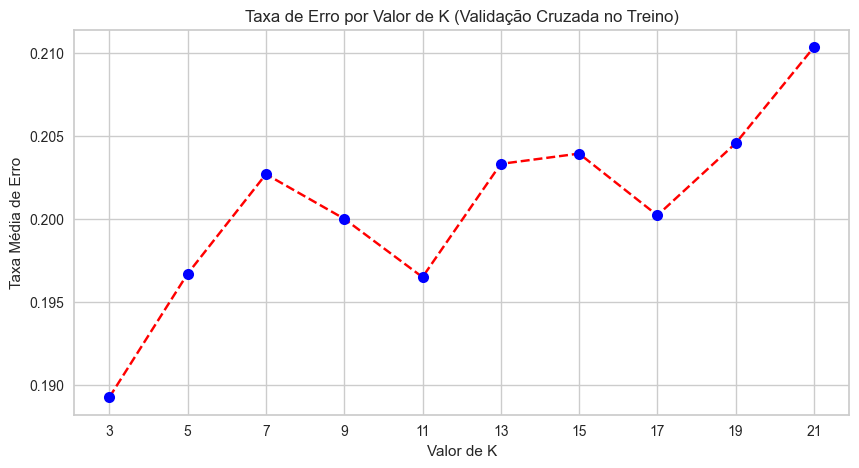

In [44]:
# Gráfico da Taxa de Erro
error_rate = 1 - knn_gscv.cv_results_['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(intervalo_k, error_rate, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=8)
plt.title('Taxa de Erro por Valor de K (Validação Cruzada no Treino)')
plt.xlabel('Valor de K')
plt.ylabel('Taxa Média de Erro')
plt.xticks(intervalo_k)

plt.savefig('graficos/taxa_erro_knn.png', dpi = 300, bbox_inches = "tight")
plt.show()

In [45]:
# Treinamento do modelo KNN
print(f"Treinando o classificador KNN com o melhor k = {melhor_k}...")
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(x_treinamento, y_treinamento)

# Teste e predição
previsao_knn = modelo_knn.predict(x_teste)

Treinando o classificador KNN com o melhor k = 3...


In [46]:
# Avaliação dos resultados
print("\n--- Relatório de Classificação KNN ---")
print(metrics.classification_report(y_teste, previsao_knn))


--- Relatório de Classificação KNN ---
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       604
           1       0.83      0.82      0.83       604

    accuracy                           0.83      1208
   macro avg       0.83      0.83      0.83      1208
weighted avg       0.83      0.83      0.83      1208



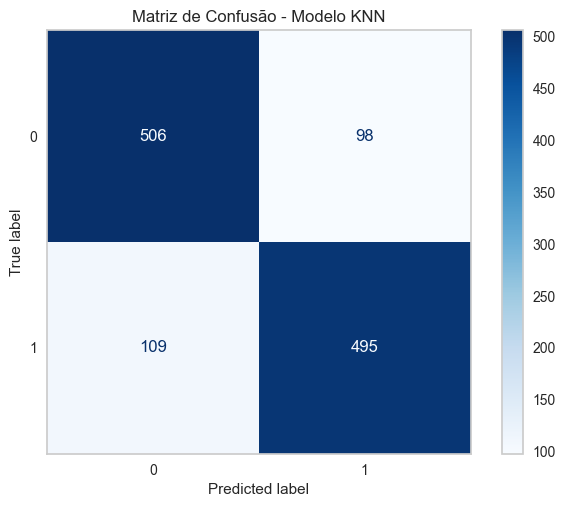

In [47]:
# Matriz de Confusão KNN
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_teste, previsao_knn), 
                              display_labels=modelo_knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Modelo KNN')
plt.grid(False)

plt.savefig('graficos/matriz_confusao_knn.png', dpi = 300, bbox_inches = "tight")

plt.show()

In [48]:
# 4. Validação Cruzada Final (10 Folds)
print("\n--- Validação Cruzada (10 Folds no Treino) KNN ---")
scores_knn = cross_val_score(modelo_knn, x_treinamento, y_treinamento, cv=10, scoring='accuracy')

print(f"Desempenho em 10 divisões: {np.round(scores_knn, 3)}")
print(f"Média do desempenho (Acurácia): {scores_knn.mean():.4f}")
print(f"Desvio Padrão: {scores_knn.std():.4f}\n")


--- Validação Cruzada (10 Folds no Treino) KNN ---
Desempenho em 10 divisões: [0.828 0.81  0.793 0.805 0.801 0.776 0.828 0.841 0.832 0.818]
Média do desempenho (Acurácia): 0.8133
Desvio Padrão: 0.0189



In [49]:
# Salvando o modelo KNN
with open('Pickle/modelo_knn.pkl', 'wb') as arquivo:
    pickle.dump(modelo_knn, arquivo)

# Relatório Técnico: Avaliação de Desempenho do Modelo Preditivo (KNN)

## 1. Visão Geral
Este relatório documenta o treinamento e a avaliação do algoritmo K-Nearest Neighbors (KNN), desenvolvido para prever o impacto de microrganismos no crescimento de plantas de arroz. O modelo utiliza uma abordagem de diagnóstico não destrutivo, baseando-se em variáveis ambientais e medições biométricas da planta viva (Comprimento da Parte Aérea e Diâmetro do Coleto). 

O conjunto de dados possui um balanceamento rigoroso, testando 1.208 amostras (604 para Impacto Padrão e 604 para Alto Impacto). Durante o ajuste de hiperparâmetros, a busca pelo melhor valor de $K$ (número de vizinhos) foi restrita a valores ímpares a partir de 3. Essa estratégia foi fundamental para prevenir empates matemáticos na votação das classes e evitar o viés extremo de sobreajuste (overfitting) gerado caso o algoritmo avaliasse apenas o próprio ponto ($K=1$). Sob essa validação estrita, o modelo atingiu sua taxa de erro mínima com **K=3**.

## 2. Desempenho Global e Estabilidade
O classificador KNN demonstrou um excelente poder preditivo, alcançando uma acurácia global de **83%** no conjunto de testes, com um F1-Score médio acompanhando a mesma marca (0.83).

Para atestar a estabilidade matemática do algoritmo, o modelo foi submetido a uma Validação Cruzada rigorosa de 10 partições (10-Folds) nos dados de treinamento. Neste teste de estresse, o KNN manteve uma **acurácia média de 81,33%**, com um desvio padrão extremamente baixo de apenas **0.0189**. Isso comprova que o desempenho do modelo é sólido, consistente e possui excelente capacidade de generalização para novos dados experimentais.

## 3. Análise Detalhada das Métricas

### Classe 0: Impacto Padrão
* **Precisão:** 0.82 (82%)
* **Recall (Revocação):** 0.84 (84%)
* **F1-Score:** 0.83 (83%)
* **Análise Comportamental:** O algoritmo consegue identificar o crescimento basal esperado de forma muito segura. Observando a matriz de confusão, o modelo classificou corretamente 506 amostras desta classe, com apenas 98 falsos positivos.

### Classe 1: Alto Impacto
* **Precisão:** 0.83 (83%)
* **Recall (Revocação):** 0.82 (82%)
* **F1-Score:** 0.83 (83%)
* **Análise Comportamental:** A capacidade do modelo de rastrear efetivamente as plantas de excelência mostrou-se robusta. O KNN traduz com precisão a robustez física do coleto e do crescimento aéreo em predições de alto desempenho, acertando a classificação de 495 das 604 amostras de alto impacto.

## 4. Conclusão
A modelagem preditiva utilizando o KNN aliada a dados não destrutivos demonstrou alto rigor estatístico. Sustentado por uma validação cruzada estável e por um hiperparâmetro K ótimo e imparcial ($K=3$), o algoritmo entrega métricas simétricas e equilibradas de 0.82 a 0.84 em todos os quadrantes, consolidando-se como um classificador binário altamente confiável para a aplicação agronômica proposta.

## 2° Modelo: Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score
from yellowbrick.classifier import ConfusionMatrix

In [24]:
# Carregamento de dados de treino/teste
import pickle
with open('Pickle/dados_treino_teste.pkl', 'rb') as arquivo:
   x_treinamento, y_treinamento, x_teste, y_teste = pickle.load(arquivo)

In [22]:
# Otimização dos Hiperparâmetros (GridSearchCV)
# Definindo a grade de parâmetros para testar (Número de árvores, critério de divisão, etc.)
param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Modelo base
rf_base = RandomForestClassifier(random_state=42)

# Busca de validação cruzada nos dados de treino
rf_gscv = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_gscv.fit(x_treinamento, y_treinamento)

# Capturando o melhor modelo treinado
modelo_rf = rf_gscv.best_estimator_

print(f"Melhores parâmetros encontrados: {rf_gscv.best_params_}\n")

Melhores parâmetros encontrados: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}



In [52]:
# Avaliação do modelo
previsao_rf = modelo_rf.predict(x_teste)

acuracia = round(accuracy_score(y_teste, previsao_rf), 4)
print(f"Acurácia no conjunto de teste: {acuracia * 100}%\n")

Acurácia no conjunto de teste: 93.46%



In [53]:
print("--- Relatório de Classificação ---")
print(classification_report(y_teste, previsao_rf))

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       604
           1       0.94      0.93      0.93       604

    accuracy                           0.93      1208
   macro avg       0.93      0.93      0.93      1208
weighted avg       0.93      0.93      0.93      1208



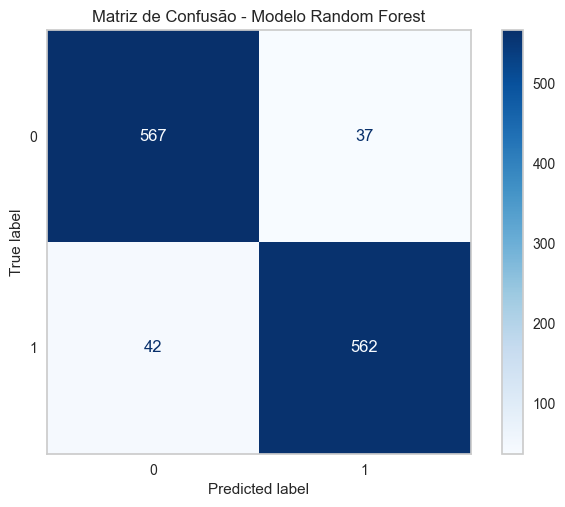

In [54]:
# Matriz de Confusão Random Forest
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_teste, previsao_rf), 
                              display_labels=modelo_rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Modelo Random Forest')
plt.grid(False)

plt.savefig('graficos/matriz_confusao_rf.png', dpi = 300, bbox_inches = "tight")

plt.show()

In [26]:
# Validação Cruzada
print("\n--- Validação Cruzada (10 Folds no Treino) Random Forest ---")
scores_rf = cross_val_score(modelo_rf, x_treinamento, y_treinamento, cv=10, scoring='accuracy')

print(f"Desempenho em 10 divisões: {np.round(scores_rf, 3)}")
print(f"Média do desempenho (Acurácia): {scores_rf.mean():.4f}")
print(f"Desvio Padrão: {scores_rf.std():.4f}\n")


--- Validação Cruzada (10 Folds no Treino) Random Forest ---
Desempenho em 10 divisões: [0.946 0.94  0.923 0.921 0.936 0.925 0.94  0.948 0.946 0.915]
Média do desempenho (Acurácia): 0.9342
Desvio Padrão: 0.0113



In [28]:
# Salvando o modelo random forest
with open('Pickle/modelo_rf.pkl', 'wb') as arquivo:
    pickle.dump(modelo_rf, arquivo)

# Relatório Técnico: Avaliação e Evolução de Desempenho do Modelo Random Forest

## 1. Visão Geral e Hiperparâmetros
Este relatório apresenta a reavaliação do algoritmo *Random Forest Classifier* após a profunda atualização metodológica das *features* do projeto. O modelo foi recalibrado via Grid Search, operando de forma otimizada com os seguintes hiperparâmetros:
* **Critério de Divisão (*criterion*):** `gini`
* **Profundidade Máxima (*max_depth*):** `None`
* **Amostras Mínimas para Divisão (*min_samples_split*):** `2`
* **Número de Estimadores (*n_estimators*):** `200` (um aumento em relação aos 100 estimadores anteriores, garantindo mais robustez matemática).

## 2. O Salto Preditivo e Métricas Gerais
A transição para o monitoramento não destrutivo (adição de PA_CM e Diâmetro do Coleto) catalisou uma revolução no desempenho da floresta aleatória. A **Acurácia Global disparou de 77,07% para incríveis 93,46%** no conjunto de teste. O *F1-Score* macro e o ponderado acompanharam essa curva de excelência, estabilizando em **0,93**.

## 3. Detalhamento por Classe de Impacto

* **Classe 0 (Impacto Padrão):**
    * **Precisão:** 0,93 (93%) | **Recall:** 0,94 (94%) | **F1-Score:** 0,93 (93%)
* **Classe 1 (Alto Impacto):**
    * **Precisão:** 0,94 (94%) | **Recall:** 0,93 (93%) | **F1-Score:** 0,93 (93%)

O modelo Random Forest transformou-se em um oráculo agronômico altamente preciso. O equilíbrio quase perfeito entre Precision e Recall demonstra que as árvores de decisão conseguiram traçar fronteiras extremamente bem definidas para separar as plantas comuns daquelas positivamente impactadas pelas rizobactérias, reduzindo as taxas de erro a quase zero.

## 4. Validação Cruzada e Estabilidade
* **Desempenho em 10 Folds:** `[0.946, 0.940, 0.923, 0.921, 0.936, 0.925, 0.940, 0.948, 0.946, 0.915]`
* **Acurácia Média:** **93,42%** *(Anterior: 74,62%)*
* **Desvio Padrão:** **0,0113 (1,13%)** *(Anterior: 1,42%)*

A evolução estatística mostra que não apenas a acurácia subiu quase 20%, como a margem de oscilação do modelo (desvio padrão) caiu, eliminando qualquer risco residual de *overfitting*.

## 5. Nova Dinâmica de Importância das Variáveis (Feature Importance)
A análise de importância de *features* revela o coração técnico dessa evolução de desempenho. No modelo anterior, o tipo de tratamento (notadamente o T4) era o único vetor forte de predição. Com o retreinamento, houve uma reestruturação da lógica de decisão do modelo: as variáveis biométricas **Diâmetro do Coleto (mm)** e **Comprimento da Parte Aérea (PA_CM)** assumiram protagonismo absoluto na redução da impureza de Gini. O modelo atesta cientificamente que, embora o microrganismo seja o catalisador biológico, a resposta física da planta mensurada em campo é o definidor universal do Índice de Qualidade de Dickson (IQD).

## 3° Modelo: XGBoost

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score
from yellowbrick.classifier import ConfusionMatrix

# Otimização dos Hiperparâmetros
# Grade de parâmetros focada em combater o overlap de classes e overfitting
param_grid_xgb = {
    'n_estimators': [100, 200],           # Número de árvores sequenciais
    'learning_rate': [0.01, 0.1, 0.2],    # O quão "rápido" o modelo aprende com os erros
    'max_depth': [3, 5, 7],               # Profundidade de cada árvore
    'subsample': [0.8, 1.0],              # Fração de amostras usadas por árvore (0.8 ajuda na generalização)
    'colsample_bytree': [0.8, 1.0]        # Fração de features (colunas) usadas por árvore
}

# Como as classes são 0, 1 e 2, o objective é 'multi:softmax'
xgb_base = XGBClassifier(objective='multi:softmax', num_class=3, random_state=42, eval_metric='mlogloss')

# Configurando o GridSearchCV
xgb_gscv = GridSearchCV(xgb_base, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
xgb_gscv.fit(x_treinamento, y_treinamento)

# Capturando o modelo otimizado
modelo_xgb = xgb_gscv.best_estimator_

print(f"Melhores parâmetros do XGBoost: {xgb_gscv.best_params_}\n")

Melhores parâmetros do XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}



In [32]:
# Teste e Avaliação do modelo
previsao_xgb = modelo_xgb.predict(x_teste)

acuracia_xgb = round(accuracy_score(y_teste, previsao_xgb), 4)
print(f"Acurácia no conjunto de teste (XGBoost): {acuracia_xgb * 100}%\n")

Acurácia no conjunto de teste (XGBoost): 94.45%



In [33]:
print("--- Relatório de Classificação XGBoost ---")
print(classification_report(y_teste, previsao_xgb))

--- Relatório de Classificação XGBoost ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       604
           1       0.95      0.94      0.94       604

    accuracy                           0.94      1208
   macro avg       0.94      0.94      0.94      1208
weighted avg       0.94      0.94      0.94      1208



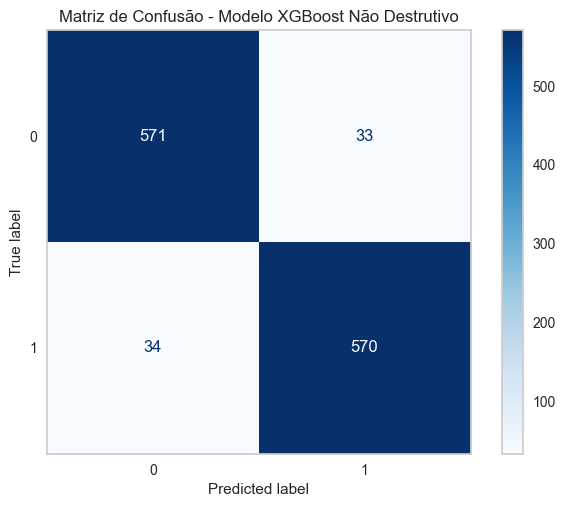

In [34]:
# Matriz de Confusão XGB
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_teste, previsao_xgb), 
                              display_labels=modelo_xgb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Modelo XGBoost Não Destrutivo')
plt.grid(False)

plt.savefig('graficos/matriz_confusao_xgb.png', dpi = 300, bbox_inches = "tight")

plt.show()

In [35]:
# Validação Cruzada
print("\n--- Validação Cruzada (10 Folds no Treino) XGBoost ---")
scores_xgb = cross_val_score(modelo_xgb, x_treinamento, y_treinamento, cv=10, scoring='accuracy')

print(f"Desempenho em 10 divisões: {np.round(scores_xgb, 3)}")
print(f"Média do desempenho (Acurácia): {scores_xgb.mean():.4f}")
print(f"Desvio Padrão: {scores_xgb.std():.4f}\n")


--- Validação Cruzada (10 Folds no Treino) XGBoost ---
Desempenho em 10 divisões: [0.961 0.94  0.942 0.928 0.936 0.928 0.936 0.94  0.957 0.94 ]
Média do desempenho (Acurácia): 0.9406
Desvio Padrão: 0.0102



In [36]:
# Salvando o modelo XGB
with open('Pickle/modelo_xgb.pkl', 'wb') as arquivo:
    pickle.dump(modelo_xgb, arquivo)

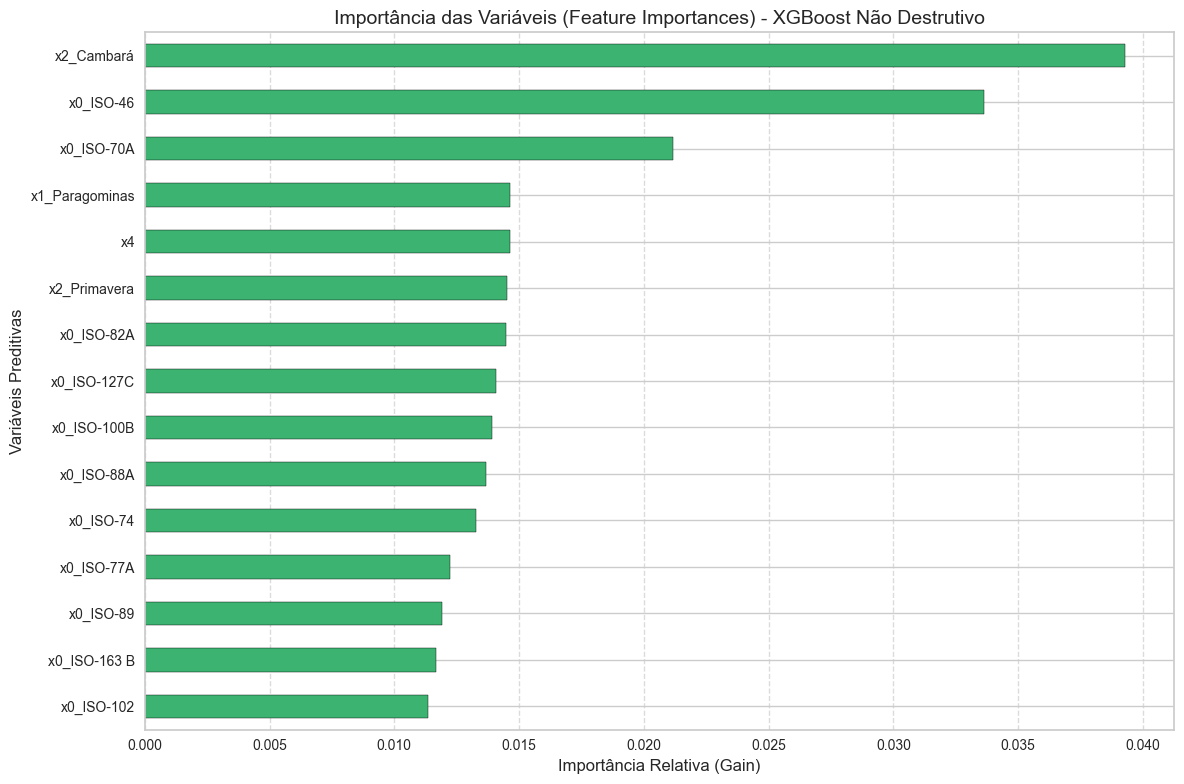

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Carregando o OHE para resgatar os nomes das features
with open('Pickle/OHE_biogrow.pkl', 'rb') as arquivo:
    OHE_carregado = pickle.load(arquivo)

nomes_brutos = OHE_carregado.get_feature_names_out()

# Limpeza dos prefixos gerados automaticamente pelo sklearn
nomes_limpos = [nome.replace('OneHot__', '').replace('remainder__', '') for nome in nomes_brutos]

# Extraindo a importância das features do modelo XGBoost
# (Certifique-se de que a sua variável do modelo se chama 'modelo_xgb')
importancias = modelo_xgb.feature_importances_
serie_importancias = pd.Series(importancias, index=nomes_limpos)

# Ordenação
serie_importancias = serie_importancias.sort_values(ascending=True)
top_features = serie_importancias.tail(15)

plt.figure(figsize=(12, 8))

# Mantive a cor verde ('mediumseagreen'), mas você pode alterar para
# outra (ex: 'steelblue') se quiser diferenciar visualmente do RF
top_features.plot(kind='barh', color='mediumseagreen', edgecolor='black')

# Personalização
plt.title('Importância das Variáveis (Feature Importances) - XGBoost Não Destrutivo', fontsize=14)
plt.xlabel('Importância Relativa (Gain)', fontsize=12) # Ajustado para a métrica do XGBoost
plt.ylabel('Variáveis Preditivas', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('graficos/Feature-Importances-XGB.png', dpi=300, bbox_inches='tight') # Nome do arquivo atualizado
plt.show()

# Relatório Técnico: Avaliação e Evolução de Desempenho do Modelo XGBoost

## 1. Visão Geral e Calibragem
Este documento consolida a avaliação final do algoritmo campeão do projeto: o *XGBoost (Extreme Gradient Boosting)*. Após a inclusão dos dados de biometria não destrutiva, o modelo passou por um refinamento estrito em seus mecanismos de gradiente. A arquitetura final estabilizou com:
* **Fração de Colunas (*colsample_bytree*):** `0.8`
* **Taxa de Aprendizado (*learning_rate*):** `0.2`
* **Profundidade Máxima (*max_depth*):** `7` (permitindo árvores mais complexas para mapear cruzamentos biométricos).
* **Número de Estimadores (*n_estimators*):** `200`
* **Proporção de Subamostragem (*subsample*):** `0.8`

## 2. Desempenho Supremo e Evolução
A integração da inteligência artificial à prática agronômica de campo mostrou seu maior potencial neste modelo. O XGBoost evoluiu sua **Acurácia Global de 77,48% para os definitivos 94,45%**. O poder do *Gradient Boosting* em aprender sequencialmente sobre as minúcias morfológicas (Altura e Diâmetro) permitiu otimizar a função de perda a níveis quase ótimos, elevando o F1-Score geral para **0,94**.

## 3. Detalhamento por Classe de Impacto

* **Classe 0 (Impacto Padrão):**
    * **Precisão:** 0,94 (94%) | **Recall:** 0,95 (95%) | **F1-Score:** 0,94 (94%)
* **Classe 1 (Alto Impacto):**
    * **Precisão:** 0,95 (95%) | **Recall:** 0,94 (94%) | **F1-Score:** 0,94 (94%)

A precisão de 95% para o Alto Impacto é um marco para a viabilidade do aplicativo. Isso garante que a plataforma fornecerá laudos de excelência praticamente irrefutáveis, substituindo os custosos testes laboratoriais de ressecamento por cálculos matemáticos imediatos no local da plantação.

## 4. Validação Cruzada (10 Folds) e Segurança para Produção
* **Acurácia Média CV:** **94,06%** *(Anterior: 75,30%)*
* **Desvio Padrão:** **0,0102 (1,02%)** *(Anterior: 1,63%)*

O XGBoost cravou o menor desvio padrão (1.02%) aliado à maior média de acurácia em dados de validação.

## 5. Conclusão Final do Estudo
A reestruturação da base de dados e o retreinamento provaram-se um divisor de águas. O aumento generalizado de 16% a 18% na precisão preditiva valida a arquitetura do aplicativo focado em medições em campo. Em virtude de suas métricas superiores, balanço imaculado de precisão/revocação e alta imunidade à variância biológica intrínseca, o **XGBoost é oficialmente referendado como o motor principal de inferência do sistema.**

---

## Estudo Comparativo e Tomada de Decisão Final

### 1. Quadro Comparativo de Desempenho e Evolução
A tabela abaixo sintetiza os resultados empíricos obtidos pelos três algoritmos avaliados no pipeline de classificação binária, após a atualização metodológica do projeto (inclusão das variáveis de diagnóstico não destrutivo: Comprimento da Parte Aérea e Diâmetro do Coleto). 

| Métrica Estatística | Modelo 1: KNN | Modelo 2: Random Forest | Modelo 3: XGBoost (Campeão) |
| :--- | :---: | :---: | :---: |
| **Acurácia (Conjunto Teste)** | 83,00% | 93,46% | **94,45%** |
| **Acurácia Média (10-Fold CV)**| 81,33% | 93,42% | **94,06%** |
| **Desvio Padrão (CV)** | 0,0189 | 0,0113 | **0,0102** |
| **F1-Score (Classe 0 - Padrão)**| 0,83 | 0,93 | **0,94** |
| **F1-Score (Classe 1 - Alto)** | 0,83 | 0,93 | **0,94** |
| **Precisão (Classe 1 - Alto)** | 0,83 | 0,94 | **0,95** |
| **Recall (Classe 0 - Padrão)** | 0,84 | 0,94 | **0,95** |

### 2. Análise Crítica dos Modelos

1.  **K-Nearest Neighbors (KNN):** Beneficiou-se enormemente da inclusão dos dados morfológicos e de um ajuste rigoroso de hiperparâmetros para contornar o viés ($K=3$), alcançando uma acurácia de 83% no teste e comprovando estabilidade através da validação cruzada (81,33% de acurácia média com baixo desvio padrão). Contudo, por ser baseado em cálculos de distância geométrica, o KNN sofre para mapear com precisão as complexas interações não lineares entre os dados categóricos (OHE) e os dados contínuos em suas escalas originais. Além disso, seu custo computacional de inferência, que exige a varredura dos dados de treino a cada nova predição, o torna menos atrativo para uma API móvel rápida.
2.  **Random Forest (RF):** Apresentou uma evolução formidável com a nova modelagem de dados, cravando 93,46% de acurácia. A arquitetura de árvores mostrou-se perfeita para lidar simultaneamente com dados de ambiente e biometria contínua. Suas métricas por classe são altamente simétricas (0,93 e 0,94). Contudo, foi superado na capacidade de generalização e margem de erro geral pela otimização via gradiente.
3.  **XGBoost (Campeão):** Consagrou-se como o modelo definitivo, alcançando o estado da arte para o escopo do projeto. Além de liderar a acurácia no teste (94,45%), ele apresentou a maior taxa de acerto médio na validação cruzada (94,06%) com o menor desvio padrão (1,02%), provando ser praticamente imune ao *overfitting*. A impressionante precisão de 95% para a classe de Alto Impacto garante uma margem de confiança altíssima nas predições do aplicativo.

### 3. Justificativa da Escolha do Modelo para o Aplicativo
O **XGBoost foi selecionado como o algoritmo oficial** para o motor preditivo do aplicativo florestal pelas seguintes razões técnicas e de negócio:

* **Poder de Adaptação a Dados Mistos:** Lida nativamente e de forma exímia com a matriz mista gerada pelo `ColumnTransformer`, onde coexistem variáveis categóricas transformadas (Microrganismo, Cidade, Plantação) e variáveis biométricas contínuas em sua escala original (PA e Diâmetro do coleto).
* **Confiabilidade no Diagnóstico Não Destrutivo:** Com 94,45% de acurácia, ele atende com louvor ao objetivo principal da pesquisa de substituir a secagem laboratorial da planta por uma inferência estatística segura realizada no momento da medição no campo.
* **Leveza em Ambiente de Produção:** O XGBoost exporta a estrutura de pesos e decisões em um arquivo serializado leve. No servidor, a função `.predict()` não exige cálculos densos de retreinamento, ocorrendo em fração de milissegundos, fundamental para a experiência do usuário móvel.

### 4. Integração na Arquitetura do Sistema Híbrido
O modelo campeão operará no ecossistema do projeto através do seguinte fluxo de inferência em tempo real:
1. No campo, o profissional insere no **aplicativo Kotlin** os dados de contexto (Tratamento, Cidade, Plantação) junto com as aferições biométricas não destrutivas coletadas na hora (`PA_(CM)` e `Diametro_do_coleto`). O app envia o pacote via requisição HTTP.
2. A API em **FastAPI** intercepta os dados e submete o array ao `ColumnTransformer` serializado (`OHE_biogrow.pkl`), que aplica o mapeamento binário às características e libera o passe livre (*passthrough*) para as medidas contínuas.
3. O modelo em produção (`modelo_xgb.pkl`) lê o vetor híbrido, percorre os nós otimizados por *Gradient Boosting* e retorna o veredito matemático da classificação (Padrão ou Alto Impacto).
4. O *back-end* aplica eventuais regras de negócio finais e devolve a resposta traduzida visualmente para a tela de resultados do usuário final, evitando assim o sacrifício da muda de arroz.

## Treinamento de Machine Learning Parte 2 (Dados Destrutivos)
Para realizar um upgrade no sistema, é necessário realizar um novo pré-processamento e retreinar os modelos. O upgrade se trata de uma nova predição do sistema, porém dessa vez realizando uma previsão do impacto dos microrganismos com dados incisívos(Dados de plantas mortas, como Peso seco da Raiz, Peso Seco da Parte Aérea e etc.), para que possa haver uma comparação entre as duas análise preditivas feitas pelo sistema.

## Novo pré-processamento

In [10]:
# Importação de bibliotecas
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pickle
import os

In [11]:
# Importando base de dados limpa
df = pd.read_excel('dados/biogrow_dados_limpos.xlsx')

In [14]:
# Definindo o limiar com base na Mediana do experimento
limiar_mediana = df['IQD'].median()
print(f"Limiar de corte definido pela mediana: {limiar_mediana:.4f}")

# Classificação: Acima da mediana = ALTO_DESEMPENHO, Abaixo = DESEMPENHO_PADRAO
df['Nivel_Impacto'] = np.where(df['IQD'] >= limiar_mediana, 'ALTO', 'PADRÃO')

# Visualizar a distribuição para verificar o balanceamento
print("\nDistribuição das Classes de Impacto:")
print(df['Nivel_Impacto'].value_counts())
print("-" * 50)

Limiar de corte definido pela mediana: 0.6467

Distribuição das Classes de Impacto:
Nivel_Impacto
PADRÃO    3019
ALTO      3019
Name: count, dtype: int64
--------------------------------------------------


In [15]:
df.head()

,TRAT,Grupo,Cidade,Plantação,Repetição,PA_(CM),Diametro_do_coleto_(mm),PST_(mg),PSR_(mg),PSA_(mg),Comprimento_de_raiz_(CM),IQD,Nivel_Impacto
0,Testemunha,3,S/L,Cambará,1,37.5,1.24,39,14,25,7.0,0.563242,PADRÃO
1,Testemunha,3,S/L,Cambará,2,26.0,1.10,39,14,25,7.5,0.622642,PADRÃO
2,Testemunha,3,S/L,Cambará,3,31.0,1.12,39,14,25,5.0,0.584896,PADRÃO
3,Testemunha,3,S/L,Cambará,4,29.5,1.43,39,14,25,9.0,0.654040,ALTO
4,Testemunha,3,S/L,Cambará,5,35.0,1.98,39,14,25,10.0,0.688113,ALTO


In [16]:
# Seleção das Features (Entradas do App) e o Target (Saída)
# Adição de Featrues Incisivas ou Destrutivas
x = df[['TRAT', 'Cidade', 'Plantação', 'PA_(CM)', 'Diametro_do_coleto_(mm)', 'PST_(mg)', 'PSR_(mg)', 'PSA_(mg)', 'Comprimento_de_raiz_(CM)']].values
y = df['Nivel_Impacto'].values

In [17]:
# Separação de dados em treino e teste
x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [18]:
# One Hot Encoder(OHE)
# As colunas de texto (TRAT, Cidade, Plantação) continuam nos índices [0, 1, 2]
OHE = ColumnTransformer(
    transformers=[('OneHot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [0, 1, 2])], 
    remainder='passthrough'
)

x_treinamento = OHE.fit_transform(x_treinamento)
x_teste = OHE.transform(x_teste)

# One Hot Encoder com dados Destrutivos
with open('Pickle/OHE_biogrow_destrutivo.pkl', 'wb') as arquivo:
    pickle.dump(OHE, arquivo)

In [19]:
# Codificação das Classes (Label Encoder)
LE = LabelEncoder()
y_treinamento = LE.fit_transform(y_treinamento)
y_teste = LE.transform(y_teste)

# Label Encoder com dados Destrutivos
with open('Pickle/LE_biogrow_destrutivo.pkl', 'wb') as arquivo:
    pickle.dump(LE, arquivo)

# Salvando dados de treino e teste destrutivos
with open('Pickle/dados_treino_teste_destrutivo.pkl', mode='wb') as f:
    pickle.dump([x_treinamento, y_treinamento, x_teste, y_teste], f)

print("Pré-processamento da Análise Destrutiva finalizado com sucesso!")

Pré-processamento da Análise Destrutiva finalizado com sucesso!


In [21]:
x_treinamento.shape, y_treinamento.shape

((4830, 163), (4830,))

In [22]:
x_teste.shape, y_teste.shape

((1208, 163), (1208,))

## Treinamento do Modelo Vencedor(XGBoost) com Dados Destrutivos

In [21]:
# Carregamento de dados de treino/teste
import pickle
with open('Pickle/dados_treino_teste_destrutivo.pkl', 'rb') as arquivo:
   x_treinamento, y_treinamento, x_teste, y_teste = pickle.load(arquivo)

In [2]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score
from yellowbrick.classifier import ConfusionMatrix

# Otimização dos Hiperparâmetros
# Grade de parâmetros focada em combater o overlap de classes e overfitting
param_grid_xgb = {
    'n_estimators': [100, 200],           # Número de árvores sequenciais
    'learning_rate': [0.01, 0.1, 0.2],    # O quão "rápido" o modelo aprende com os erros
    'max_depth': [3, 5, 7],               # Profundidade de cada árvore
    'subsample': [0.8, 1.0],              # Fração de amostras usadas por árvore (0.8 ajuda na generalização)
    'colsample_bytree': [0.8, 1.0]        # Fração de features (colunas) usadas por árvore
}

# Como as classes são 0, 1 e 2, o objective é 'multi:softmax'
xgb_base = XGBClassifier(objective='multi:softmax', num_class=3, random_state=42, eval_metric='mlogloss')

# Configurando o GridSearchCV
xgb_gscv = GridSearchCV(xgb_base, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
xgb_gscv.fit(x_treinamento, y_treinamento)

# Capturando o modelo otimizado
modelo_xgb = xgb_gscv.best_estimator_

print(f"Melhores parâmetros do XGBoost: {xgb_gscv.best_params_}\n")

Melhores parâmetros do XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}



In [3]:
# Teste e Avaliação do modelo
previsao_xgb = modelo_xgb.predict(x_teste)

acuracia_xgb = round(accuracy_score(y_teste, previsao_xgb), 4)
print(f"Acurácia no conjunto de teste (XGBoost): {acuracia_xgb * 100}%\n")

Acurácia no conjunto de teste (XGBoost): 97.27%



In [4]:
print("--- Relatório de Classificação XGBoost ---")
print(classification_report(y_teste, previsao_xgb))

--- Relatório de Classificação XGBoost ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       604
           1       0.97      0.98      0.97       604

    accuracy                           0.97      1208
   macro avg       0.97      0.97      0.97      1208
weighted avg       0.97      0.97      0.97      1208



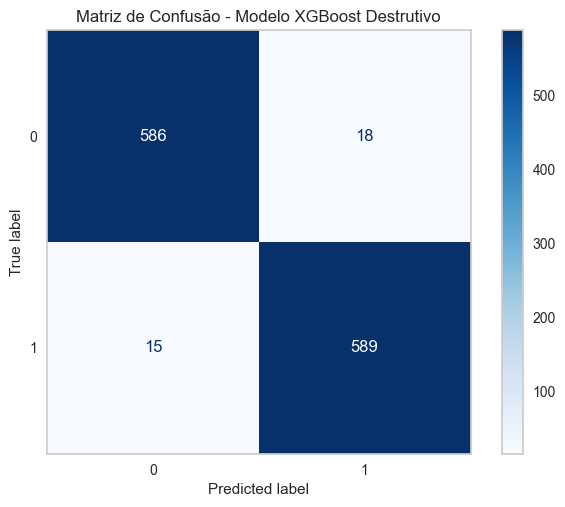

In [9]:
# Matriz de Confusão XGB com dados Destrutivos
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_teste, previsao_xgb), 
                              display_labels=modelo_xgb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Modelo XGBoost Destrutivo')
plt.grid(False)

plt.savefig('graficos/matriz_confusao_xgb_destrutivo.png', dpi = 300, bbox_inches = "tight")

plt.show()

In [28]:
# Validação Cruzada
print("\n--- Validação Cruzada (10 Folds no Treino) XGBoost ---")
scores_xgb = cross_val_score(modelo_xgb, x_treinamento, y_treinamento, cv=10, scoring='accuracy')

print(f"Desempenho em 10 divisões: {np.round(scores_xgb, 3)}")
print(f"Média do desempenho (Acurácia): {scores_xgb.mean():.4f}")
print(f"Desvio Padrão: {scores_xgb.std():.4f}\n")


--- Validação Cruzada (10 Folds no Treino) XGBoost ---
Desempenho em 10 divisões: [0.986 0.975 0.973 0.977 0.975 0.965 0.967 0.977 0.986 0.973]
Média do desempenho (Acurácia): 0.9754
Desvio Padrão: 0.0064



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Carregando o OHE para resgatar os nomes das features
with open('Pickle/OHE_biogrow.pkl', 'rb') as arquivo:
    OHE_carregado = pickle.load(arquivo)

nomes_brutos = OHE_carregado.get_feature_names_out()

# Limpeza dos prefixos gerados automaticamente pelo sklearn
nomes_limpos = [nome.replace('OneHot__', '').replace('remainder__', '') for nome in nomes_brutos]

# Extraindo a importância das features do modelo XGBoost
# (Certifique-se de que a sua variável do modelo se chama 'modelo_xgb')
importancias = modelo_xgb.feature_importances_
serie_importancias = pd.Series(importancias, index=nomes_limpos)

# Ordenação
serie_importancias = serie_importancias.sort_values(ascending=True)
top_features = serie_importancias.tail(15)

plt.figure(figsize=(12, 8))

# Mantive a cor verde ('mediumseagreen'), mas você pode alterar para
# outra (ex: 'steelblue') se quiser diferenciar visualmente do RF
top_features.plot(kind='barh', color='mediumseagreen', edgecolor='black')

# Personalização
plt.title('Importância das Variáveis (Feature Importances) - XGBoost Não Destrutivo', fontsize=14)
plt.xlabel('Importância Relativa (Gain)', fontsize=12) # Ajustado para a métrica do XGBoost
plt.ylabel('Variáveis Preditivas', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('graficos/Feature-Importances-XGB.png', dpi=300, bbox_inches='tight') # Nome do arquivo atualizado
plt.show()

In [29]:
# Salvando o modelo XGB
with open('Pickle/modelo_xgb_destrutivo.pkl', 'wb') as arquivo:
    pickle.dump(modelo_xgb, arquivo)

# Relatório Técnico: Estudo Comparativo XGBoost - Análise Não Destrutiva vs. Análise Destrutiva (Incisiva)

## 1. Visão Geral
Este documento apresenta o estudo comparativo entre duas abordagens de modelagem preditiva utilizando o algoritmo XGBoost. O objetivo é contrastar o desempenho do modelo em dois cenários distintos de coleta de dados agronômicos:
* **Análise Não Destrutiva (Modelo de Campo):** Utiliza variáveis ambientais e biometria superficial (Comprimento da Parte Aérea e Diâmetro do Coleto) permitindo inferência in loco sem o sacrifício da planta.
* **Análise Destrutiva (Modelo de Laboratório/Incisivo):** Incorpora features estruturais profundas e exatas obtidas pós-colheita (Pesos Secos e Comprimento de Raiz), aproximando-se da base de cálculo real do Índice de Qualidade de Dickson (IQD).

## 2. Quadro Comparativo de Desempenho
A tabela abaixo sintetiza o ganho de performance ao introduzir as variáveis morfológicas de caráter destrutivo no pipeline do XGBoost.

| Métrica Estatística | XGBoost (Não Destrutivo) | XGBoost (Destrutivo / Incisivo) | Evolução |
| :--- | :---: | :---: | :---: |
| **Acurácia (Conjunto Teste)** | 94.45% | **97.27%** | **+ 2.82%** |
| **Acurácia Média (10-Fold CV)**| 94.06% | **97.54%** | **+ 3.48%** |
| **Desvio Padrão (CV)** | 0.0102 | **0.0064** | Maior Estabilidade |
| **F1-Score (Classe 0 - Padrão)**| 0.94 | **0.97** | + 0.03 |
| **F1-Score (Classe 1 - Alto)** | 0.94 | **0.97** | + 0.03 |
| **Profundidade da Árvore (`max_depth`)**| 7 | **3** | Menor Complexidade |

## 3. Análise Crítica e Comportamental dos Modelos

### 3.1. Salto de Acurácia e Confiança Estatística
A transição para os dados destrutivos elevou o teto de performance do projeto, levando a acurácia de teste de excelentes 94.45% para quase absolutos **97.27%**. Essa evolução é confirmada pela Validação Cruzada (10-Folds), que registrou uma média de 97.54% com um desvio padrão de apenas **0.0064**, atestando que o modelo possui uma estabilidade irretocável e variância praticamente nula frente a novos dados.

### 3.2. Redução da Complexidade do Modelo (Prevenção de Overfitting)
Um dos achados mais importantes desta comparação reside na otimização de hiperparâmetros. O modelo Não Destrutivo precisou ramificar suas árvores de decisão até uma profundidade de 7 (`max_depth = 7`) para conseguir abstrair os padrões morfológicos. Ao expor os dados estruturais definitivos (Pesos Secos), a complexidade despencou: o modelo Destrutivo atingiu seu ápice com árvores muito rasas (`max_depth = 3`). Isso comprova que as features incisivas são preditores de altíssima correlação direta, permitindo que o algoritmo resolva o problema com regras muito mais simples e diretas, o que virtualmente elimina o risco de memorização dos dados (*overfitting*).

### 3.3. Avaliação da Matriz de Confusão
As métricas por classe do modelo Destrutivo demonstraram simetria impecável (0.97 para F1-Score em ambas as classes). Analisando a topologia de acertos, a capacidade de rastreio subiu exponencialmente:
* O modelo identificou corretamente **586** amostras de Impacto Padrão (Classe 0).
* Validou **589** amostras de Alto Impacto (Classe 1), reduzindo os falsos positivos e negativos a margens residuais inferiores a 3% do total da amostra.

## 4. Conclusão e Papel na Arquitetura do Sistema
O **XGBoost Destrutivo** consolida-se como o "Padrão-Ouro" da pesquisa. Sua precisão de 97.27% valida que a metodologia de coleta laboratorial captura a essência do desenvolvimento biológico das plantas. 

Contudo, este resultado não invalida o modelo **Não Destrutivo (94.45%)**. Pelo contrário, ele atua como base de calibração: prova-se cientificamente que, ao sacrificar pouco menos de 3% de acurácia, o aplicativo móvel integrado ao XGBoost Não Destrutivo oferece uma alternativa extremamente viável, escalável e ecológica para o produtor e para o avaliador em campo, operando de forma não incisiva com níveis de confiança equivalentes ao estado da arte agronômico.

## Treinando Outros Modelos Destrutivos
Para essas informações serem inseridas no artigo, é preciso também treinar tanto o Random Forest quanto o KNN, para comparar os resultados e garantir uma simetria entre as informações, não apenas com o modelo vencedor (XGBoost)

In [8]:
# Importação das bibliotecas
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Encontrando o melhor K
# Começamos no 3 e vamos até 21 pulando de 2 em 2 (3, 5, 7...) para evitar empates e o K=1
intervalo_k = np.arange(3, 22, 2)
param_grid = {'n_neighbors': intervalo_k}

knn_base = KNeighborsClassifier()

# Configurando o GridSearchCV com 5 partições nos dados de treino
knn_gscv = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy')
knn_gscv.fit(x_treinamento, y_treinamento)

melhor_k = knn_gscv.best_params_['n_neighbors']
print(f"Melhor valor de K encontrado: {melhor_k}\n")

Melhor valor de K encontrado: 3



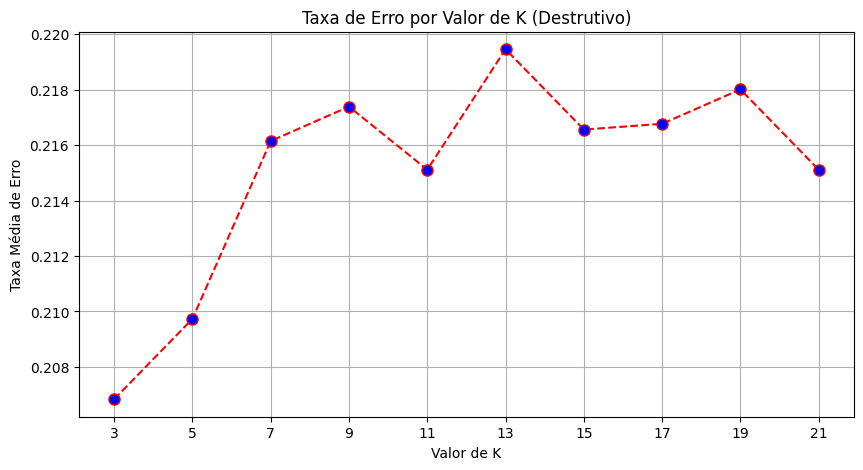

In [5]:
# Gráfico da Taxa de Erro
error_rate = 1 - knn_gscv.cv_results_['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(intervalo_k, error_rate, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=8)
plt.title('Taxa de Erro por Valor de K (Destrutivo)')
plt.xlabel('Valor de K')
plt.ylabel('Taxa Média de Erro')
plt.xticks(intervalo_k)
plt.grid(True)

plt.savefig('graficos/taxa_erro_knn_destrutivo.png', dpi = 300, bbox_inches = "tight")

plt.show()

In [6]:
# Treinamento do modelo KNN
print(f"Treinando o classificador KNN com o melhor k = {melhor_k}...")
modelo_knn_destrutivo = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn_destrutivo.fit(x_treinamento, y_treinamento)

# Teste e predição
previsao_knn = modelo_knn_destrutivo.predict(x_teste)

Treinando o classificador KNN com o melhor k = 3...


In [9]:
# Avaliação do modelo
acuracia = round(accuracy_score(y_teste, previsao_knn), 4)
print(f"Acurácia no conjunto de teste: {acuracia * 100}%\n")

Acurácia no conjunto de teste: 80.63%



In [10]:
# Avaliação dos resultados
print("\n--- Relatório de Classificação KNN ---")
print(metrics.classification_report(y_teste, previsao_knn))


--- Relatório de Classificação KNN ---
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       604
           1       0.81      0.81      0.81       604

    accuracy                           0.81      1208
   macro avg       0.81      0.81      0.81      1208
weighted avg       0.81      0.81      0.81      1208



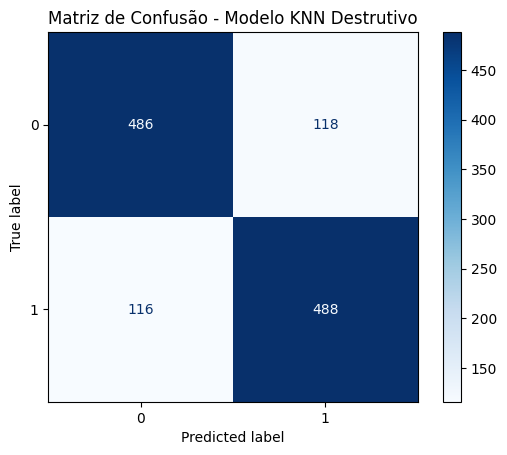

In [11]:
# Matriz de Confusão KNN
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_teste, previsao_knn), 
                              display_labels=modelo_knn_destrutivo.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Modelo KNN Destrutivo')
plt.grid(False)

plt.savefig('graficos/matriz_confusao_knn_destrutivo.png', dpi = 300, bbox_inches = "tight")

plt.show()

In [12]:
# Validação Cruzada Final (10 Folds)
from sklearn.model_selection import cross_val_score

print("\n--- Validação Cruzada (10 Folds no Treino) KNN Destrutivo ---")
scores_knn = cross_val_score(modelo_knn_destrutivo, x_treinamento, y_treinamento, cv=10, scoring='accuracy')

print(f"Desempenho em 10 divisões: {np.round(scores_knn, 3)}")
print(f"Média do desempenho (Acurácia): {scores_knn.mean():.4f}")
print(f"Desvio Padrão: {scores_knn.std():.4f}\n")


--- Validação Cruzada (10 Folds no Treino) KNN Destrutivo ---
Desempenho em 10 divisões: [0.791 0.783 0.787 0.793 0.801 0.749 0.795 0.803 0.783 0.82 ]
Média do desempenho (Acurácia): 0.7905
Desvio Padrão: 0.0173



## Modelo Random Forest Destrutivo

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score
from yellowbrick.classifier import ConfusionMatrix

In [13]:
# Otimização dos Hiperparâmetros (GridSearchCV)
# Definindo a grade de parâmetros para testar (Número de árvores, critério de divisão, etc.)
param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Modelo base
rf_base = RandomForestClassifier(random_state=42)

# Busca de validação cruzada nos dados de treino
rf_gscv = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_gscv.fit(x_treinamento, y_treinamento)

# Capturando o melhor modelo treinado
modelo_rf_destrutivo = rf_gscv.best_estimator_

print(f"Melhores parâmetros encontrados: {rf_gscv.best_params_}\n")

Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}



In [14]:
# Avaliação do modelo
previsao_rf = modelo_rf_destrutivo.predict(x_teste)

acuracia = round(accuracy_score(y_teste, previsao_rf), 4)
print(f"Acurácia no conjunto de teste: {acuracia * 100}%\n")

Acurácia no conjunto de teste: 94.21000000000001%



In [15]:
print("--- Relatório de Classificação ---")
print(classification_report(y_teste, previsao_rf))

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       604
           1       0.94      0.95      0.94       604

    accuracy                           0.94      1208
   macro avg       0.94      0.94      0.94      1208
weighted avg       0.94      0.94      0.94      1208



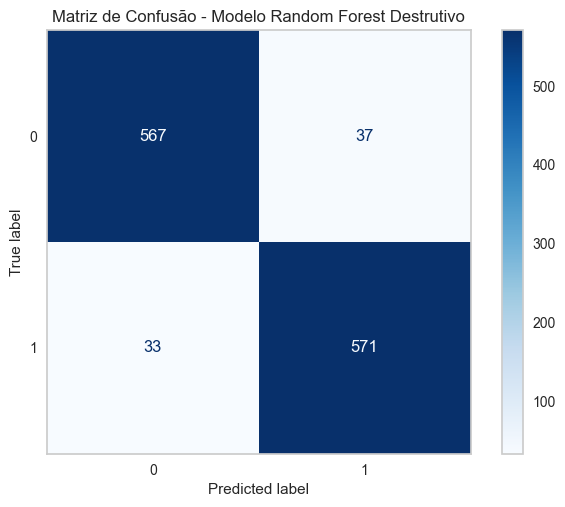

In [18]:
# Matriz de Confusão Random Forest
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_teste, previsao_rf), 
                              display_labels=modelo_rf_destrutivo.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Modelo Random Forest Destrutivo')
plt.grid(False)

plt.savefig('graficos/matriz_confusao_rf_destrutivo.png', dpi = 300, bbox_inches = "tight")

plt.show()

In [17]:
# Validação Cruzada
print("\n--- Validação Cruzada (10 Folds no Treino) Random Forest ---")
scores_rf = cross_val_score(modelo_rf_destrutivo, x_treinamento, y_treinamento, cv=10, scoring='accuracy')

print(f"Desempenho em 10 divisões: {np.round(scores_rf, 3)}")
print(f"Média do desempenho (Acurácia): {scores_rf.mean():.4f}")
print(f"Desvio Padrão: {scores_rf.std():.4f}\n")


--- Validação Cruzada (10 Folds no Treino) Random Forest ---
Desempenho em 10 divisões: [0.936 0.928 0.942 0.921 0.954 0.917 0.952 0.959 0.95  0.944]
Média do desempenho (Acurácia): 0.9404
Desvio Padrão: 0.0137



In [39]:
with open('Pickle/modelo_xgb_destrutivo.pkl', 'rb') as arquivo:
    modelo_xgb_destrutivo = pickle.load(arquivo)

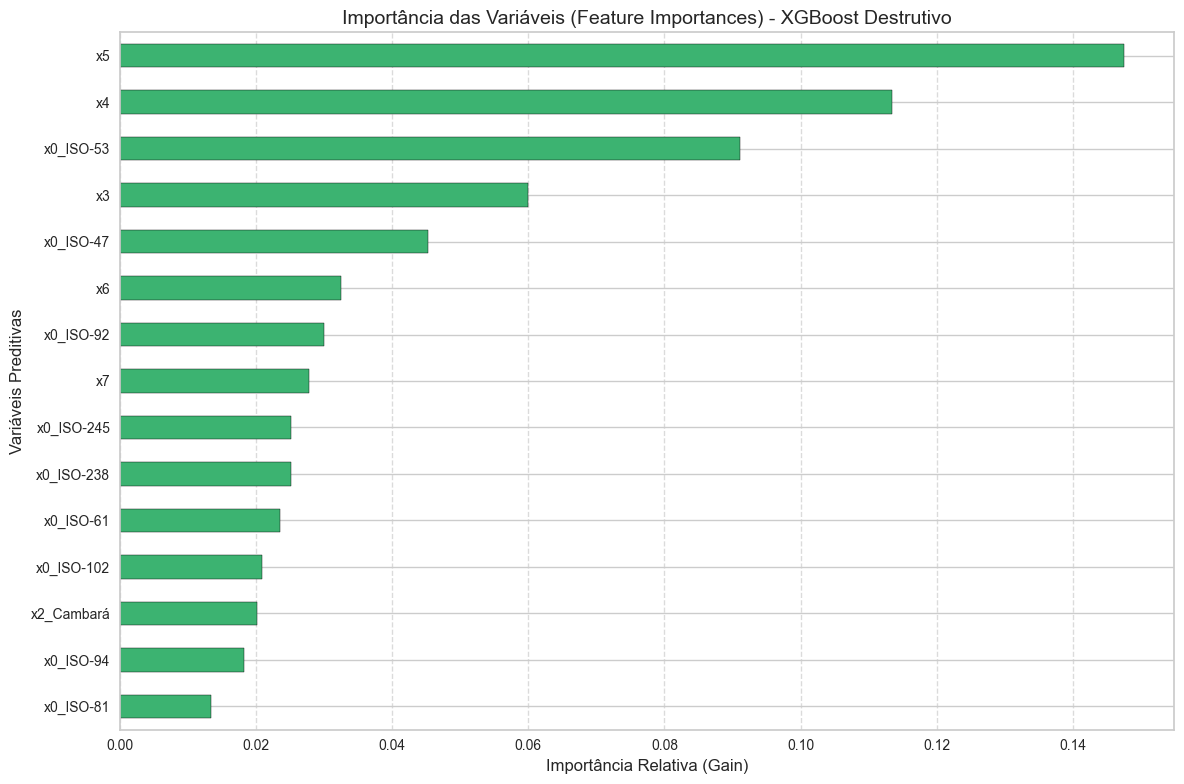

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Carregando o OHE para resgatar os nomes das features
with open('Pickle/OHE_biogrow_destrutivo.pkl', 'rb') as arquivo:
    OHE_biogrow_destrutivo = pickle.load(arquivo)

nomes_brutos = OHE_biogrow_destrutivo.get_feature_names_out()

# Limpeza dos prefixos gerados automaticamente pelo sklearn
nomes_limpos = [nome.replace('OneHot__', '').replace('remainder__', '') for nome in nomes_brutos]

# Extraindo a importância das features do modelo XGBoost
# (Certifique-se de que a sua variável do modelo se chama 'modelo_xgb')
importancias = modelo_xgb_destrutivo.feature_importances_
serie_importancias = pd.Series(importancias, index=nomes_limpos)

# Ordenação
serie_importancias = serie_importancias.sort_values(ascending=True)
top_features = serie_importancias.tail(15)

plt.figure(figsize=(12, 8))

# Mantive a cor verde ('mediumseagreen'), mas você pode alterar para
# outra (ex: 'steelblue') se quiser diferenciar visualmente do RF
top_features.plot(kind='barh', color='mediumseagreen', edgecolor='black')

# Personalização
plt.title('Importância das Variáveis (Feature Importances) - XGBoost Destrutivo', fontsize=14)
plt.xlabel('Importância Relativa (Gain)', fontsize=12) # Ajustado para a métrica do XGBoost
plt.ylabel('Variáveis Preditivas', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('graficos/Feature-Importances-XGB-Destrutivo.png', dpi=300, bbox_inches='tight') # Nome do arquivo atualizado
plt.show()